# TRT Pharmacokinetic Analysis
## Testosterone Replacement Therapy — Dose-Response, Cofactor Impact & Protocol Optimisation

**Subject:** Male, 15 months on TRT (Testosterone Cypionate 200mg/ml, subcutaneous, twice-weekly)  
**Provider:** Manual (manual.co)  
**Analysis Period:** January 2025 – May 2026  
**Blood Tests:** 6 panels (baseline + 5 on-treatment)  
**Clinical Framework:** BSSM Guidelines on Adult Testosterone Deficiency (Hackett et al., 2017; updated 2023)

### BSSM Treatment Targets (On-Treatment Trough)
| Marker | Target Range | Source |
|---|---|---|
| Total Testosterone | 15–30 nmol/L | BSSM 2017/2023 |
| Free Testosterone | 0.225–0.500 nmol/L | BSSM / Vermeulen calculation |
| Haematocrit | < 0.54 (safety ceiling) | BSSM 2017 |
| PSA | < 1.4 ng/mL rise from baseline in 12 months | BSSM 2017 |

### Clinical Question
> After 15 months on TRT with gradual dose escalation (56 → 78.4 mg active T/week), the latest trough total testosterone is 12.7 nmol/L — below the BSSM minimum treatment target of 15 nmol/L. This coincides with cessation of a cofactor supplement stack (Boron, Zinc, Magnesium, Selenium, P5P) that was suppressing SHBG. The data suggests the current protocol may not be achieving adequate trough levels independently of supplementation.
>
> This analysis is prepared to support an evidence-based discussion with my clinician at Manual regarding dose optimisation and potential protocol adjustments.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "lines.linewidth": 2,
    "figure.facecolor": "white",
})

PURPLE = "#7A6FBE"
GREEN = "#50B88E"
ORANGE = "#E8915A"
BLUE = "#4A90D9"
RED = "#E63946"
GREY = "#8B8D97"

DATA_DIR = Path("..") / "data" / "processed"
RAW_DIR = Path("..") / "data" / "raw"
print("Setup complete.")

Setup complete.


In [2]:
bloodwork = pd.read_csv(DATA_DIR / "bloodwork.csv", parse_dates=["date"])
sleep = pd.read_csv(DATA_DIR / "sleep.csv", parse_dates=["day"])
readiness = pd.read_csv(DATA_DIR / "readiness.csv", parse_dates=["day"])
stress = pd.read_csv(DATA_DIR / "stress.csv", parse_dates=["day"])
activity = pd.read_csv(DATA_DIR / "activity.csv", parse_dates=["day"])
workouts = pd.read_csv(DATA_DIR / "workouts.csv", parse_dates=["day"])
nutrition = pd.read_csv(DATA_DIR / "nutrition.csv", parse_dates=["date"])
body_comp = pd.read_csv(DATA_DIR / "body_composition.csv", parse_dates=["date"])
heartrate = pd.read_parquet(DATA_DIR / "heartrate.parquet")
if "day" in heartrate.columns:
    heartrate["day"] = pd.to_datetime(heartrate["day"])

trt = pd.read_csv(RAW_DIR / "trt" / "trt_dose_history.csv", parse_dates=["date"])

for df in [bloodwork, sleep, readiness, stress, activity, nutrition, body_comp]:
    date_col = "date" if "date" in df.columns else "day"
    df.sort_values(date_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"Bloodwork tests:    {len(bloodwork)}")
print(f"Sleep days:         {len(sleep)}")
print(f"Readiness days:     {len(readiness)}")
print(f"Stress days:        {len(stress)}")
print(f"Activity days:      {len(activity)}")
print(f"Workout sets:       {len(workouts)}")
print(f"Nutrition days:     {len(nutrition)}")
print(f"Body comp scans:    {len(body_comp)}")
print(f"TRT dose events:    {len(trt)}")

Bloodwork tests:    6
Sleep days:         470
Readiness days:     470
Stress days:        486
Activity days:      488
Workout sets:       11508
Nutrition days:     217
Body comp scans:    79
TRT dose events:    8


In [3]:
CONC_MG_PER_ML = 200
ESTER_FACTOR = 0.70

phases = [
    {"label": "Pre-TRT (Baseline)", "start": "2025-01-29", "end": "2025-02-14",
     "dose_ml": 0, "freq": "none", "colour": GREY},
    {"label": "Phase 1: 0.20ml 2x/wk", "start": "2025-02-15", "end": "2025-05-12",
     "dose_ml": 0.20, "freq": "twice_weekly", "colour": BLUE},
    {"label": "Phase 2: 0.23ml 2x/wk", "start": "2025-05-13", "end": "2025-08-25",
     "dose_ml": 0.23, "freq": "twice_weekly", "colour": GREEN},
    {"label": "Phase 3: 0.26ml 2x/wk (prescribed)", "start": "2025-08-26", "end": "2026-05-09",
     "dose_ml": 0.26, "freq": "twice_weekly", "colour": ORANGE,
     "actual_ml": 0.28, "note": "Prescribed 0.26ml; actual 0.28ml due to misread"},
]

for p in phases:
    p["start"] = pd.Timestamp(p["start"])
    p["end"] = pd.Timestamp(p["end"])
    p["weekly_mg_cypionate"] = p["dose_ml"] * CONC_MG_PER_ML * 2
    p["weekly_mg_active_T"] = p["weekly_mg_cypionate"] * ESTER_FACTOR
    if "actual_ml" in p:
        p["actual_mg_cypionate_weekly"] = p["actual_ml"] * CONC_MG_PER_ML * 2
        p["actual_mg_active_T_weekly"] = p["actual_mg_cypionate_weekly"] * ESTER_FACTOR

COFACTOR_STOP_START = pd.Timestamp("2026-02-12")
COFACTOR_STOP_END = pd.Timestamp("2026-05-03")

phase_df = pd.DataFrame(phases)
print(phase_df[["label", "weekly_mg_cypionate", "weekly_mg_active_T"]].to_string(index=False))
print("\nNote: Phase 3 prescribed 0.26ml but actual dosing was 0.28ml (misread).")
print(f"  Prescribed: {0.26*200*2:.0f}mg cypionate / {0.26*200*2*0.70:.1f}mg active T per week")
print(f"  Actual:     {0.28*200*2:.0f}mg cypionate / {0.28*200*2*0.70:.1f}mg active T per week")

                             label  weekly_mg_cypionate  weekly_mg_active_T
                Pre-TRT (Baseline)                  0.0                 0.0
             Phase 1: 0.20ml 2x/wk                 80.0                56.0
             Phase 2: 0.23ml 2x/wk                 92.0                64.4
Phase 3: 0.26ml 2x/wk (prescribed)                104.0                72.8

Note: Phase 3 prescribed 0.26ml but actual dosing was 0.28ml (misread).
  Prescribed: 104mg cypionate / 72.8mg active T per week
  Actual:     112mg cypionate / 78.4mg active T per week


---
## 2. TRT Timeline Overview
Master timeline showing dose escalation, blood test results, and key events.

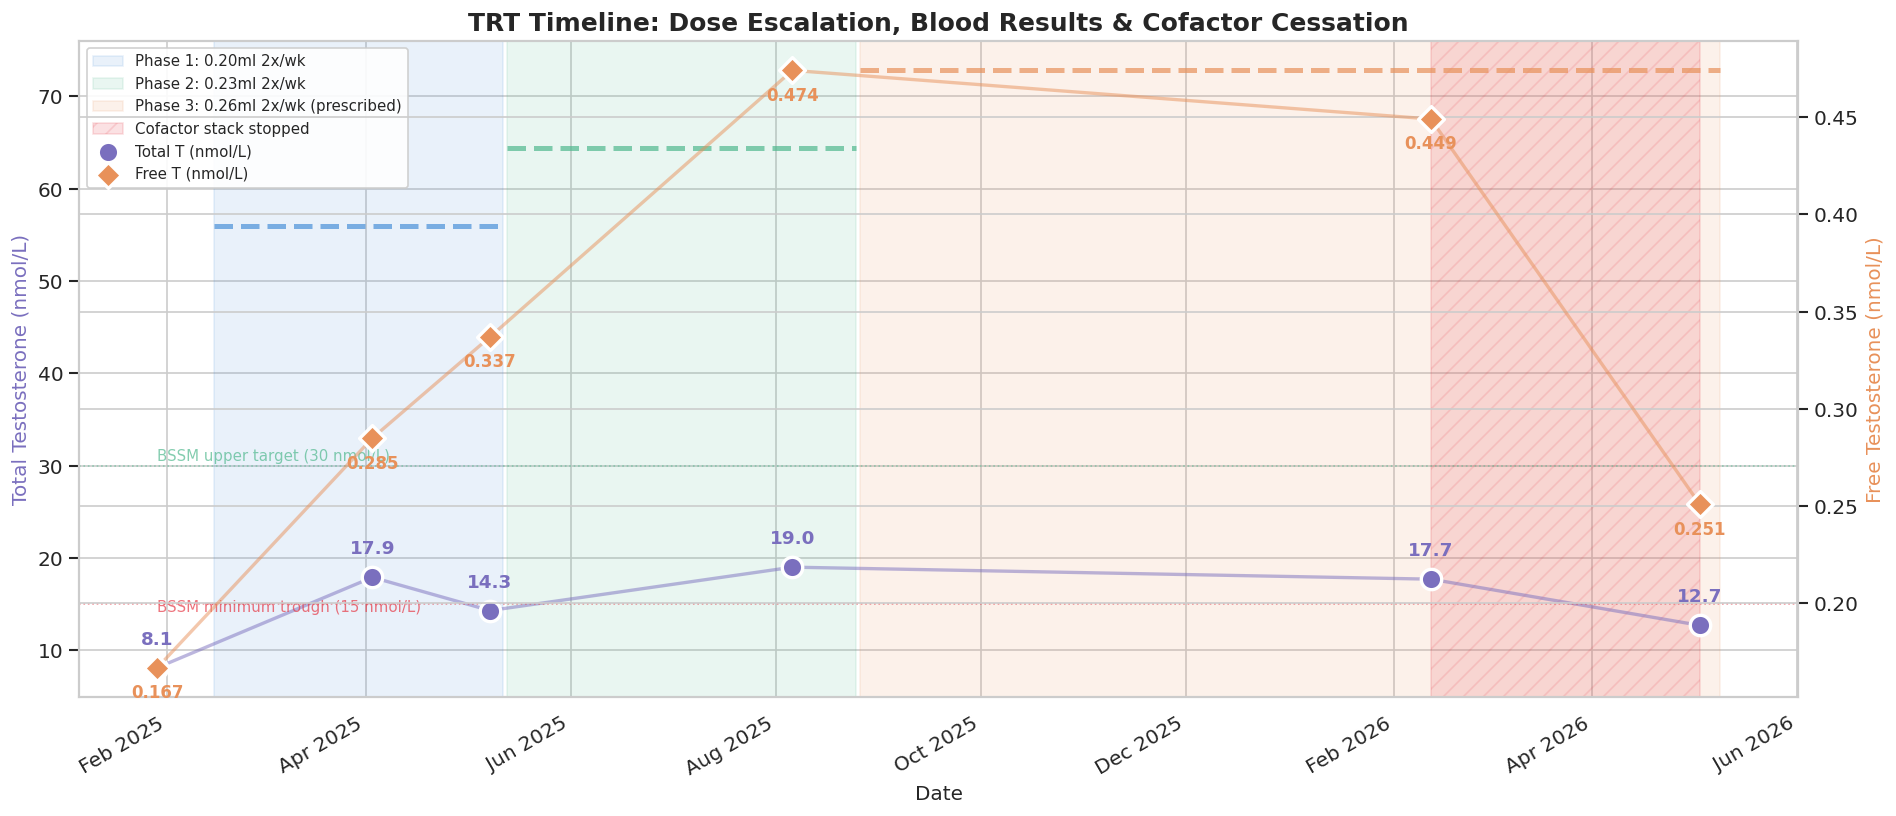

In [4]:
fig, ax1 = plt.subplots(figsize=(16, 7))

for p in phases:
    if p["dose_ml"] > 0:
        ax1.axvspan(p["start"], p["end"], alpha=0.12, color=p["colour"], label=p["label"])
        ax1.hlines(p["weekly_mg_active_T"], p["start"], p["end"],
                   colors=p["colour"], linewidth=3, linestyle="--", alpha=0.7)

ax1.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.15, color=RED,
            hatch="//", label="Cofactor stack stopped")

bt = bloodwork.dropna(subset=["testosterone_nmol"])
ax1.scatter(bt["date"], bt["testosterone_nmol"], s=150, c=PURPLE, zorder=5,
            edgecolors="white", linewidth=2, label="Total T (nmol/L)")
ax1.plot(bt["date"], bt["testosterone_nmol"], color=PURPLE, alpha=0.5, linestyle="-")

for _, row in bt.iterrows():
    ax1.annotate(f'{row["testosterone_nmol"]:.1f}',
                 (row["date"], row["testosterone_nmol"]),
                 textcoords="offset points", xytext=(0, 14),
                 fontsize=11, fontweight="bold", color=PURPLE, ha="center")

ax1.axhline(y=15, color=RED, linestyle=":", alpha=0.5, linewidth=1)
ax1.axhline(y=30, color=GREEN, linestyle=":", alpha=0.5, linewidth=1)
ax1.text(bt["date"].min(), 14.2, "BSSM minimum trough (15 nmol/L)", fontsize=9, color=RED, alpha=0.7)
ax1.text(bt["date"].min(), 30.5, "BSSM upper target (30 nmol/L)", fontsize=9, color=GREEN, alpha=0.7)

ax2 = ax1.twinx()
ft = bloodwork.dropna(subset=["free_testosterone_nmol"])
ax2.scatter(ft["date"], ft["free_testosterone_nmol"], s=120, c=ORANGE, marker="D",
            zorder=5, edgecolors="white", linewidth=2, label="Free T (nmol/L)")
ax2.plot(ft["date"], ft["free_testosterone_nmol"], color=ORANGE, alpha=0.5, linestyle="-")

for _, row in ft.iterrows():
    ax2.annotate(f'{row["free_testosterone_nmol"]:.3f}',
                 (row["date"], row["free_testosterone_nmol"]),
                 textcoords="offset points", xytext=(0, -18),
                 fontsize=10, fontweight="bold", color=ORANGE, ha="center")

ax1.set_xlabel("Date")
ax1.set_ylabel("Total Testosterone (nmol/L)", color=PURPLE)
ax2.set_ylabel("Free Testosterone (nmol/L)", color=ORANGE)
ax1.set_title("TRT Timeline: Dose Escalation, Blood Results & Cofactor Cessation", fontsize=15, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

In [5]:
def get_phase_label(date):
    for p in phases:
        if p["start"] <= date <= p["end"]:
            return p["label"]
    return "Unknown"

def get_dose(date):
    for p in reversed(phases):
        if date >= p["start"]:
            return p["weekly_mg_active_T"]
    return 0

bloodwork["phase"] = bloodwork["date"].apply(get_phase_label)
bloodwork["dose_mg_active_T"] = bloodwork["date"].apply(get_dose)
bloodwork["free_androgen_index"] = (bloodwork["testosterone_nmol"] / bloodwork["shbg_nmol"]) * 100
bloodwork["free_t_pct"] = (bloodwork["free_testosterone_nmol"] / bloodwork["testosterone_nmol"]) * 100

display_cols = ["date", "phase", "dose_mg_active_T", "testosterone_nmol",
                "free_testosterone_nmol", "shbg_nmol", "oestradiol_pmol",
                "free_androgen_index", "free_t_pct"]
summary = bloodwork[display_cols].copy()
summary.columns = ["Date", "TRT Phase", "Active T mg/wk", "Total T",
                    "Free T", "SHBG", "E2", "FAI", "Free T %"]
summary = summary.round(2)
print("=== Blood Test Results Across TRT Phases ===")
print(summary.to_string(index=False))

=== Blood Test Results Across TRT Phases ===
      Date                          TRT Phase  Active T mg/wk  Total T  Free T  SHBG    E2   FAI  Free T %
2025-01-29                 Pre-TRT (Baseline)             0.0     8.12    0.17  28.6  38.6 28.39      2.06
2025-04-03              Phase 1: 0.20ml 2x/wk            56.0    17.90    0.28  33.8 135.0 52.96      1.59
2025-05-08              Phase 1: 0.20ml 2x/wk            56.0    14.30    0.34  23.2  75.0 61.64      2.36
2025-08-06              Phase 2: 0.23ml 2x/wk            64.4    19.00    0.47  23.2 117.0 81.90      2.49
2026-02-12 Phase 3: 0.26ml 2x/wk (prescribed)            72.8    17.70    0.45  22.5  86.8 78.67      2.54
2026-05-03 Phase 3: 0.26ml 2x/wk (prescribed)            72.8    12.70    0.25  32.1  95.1 39.56      1.98


/tmp/ipykernel_111996/909235434.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  summary = summary.round(2)


---
## 3. Dose-Response Analysis
Examining the relationship between exogenous testosterone dose and resulting serum levels.

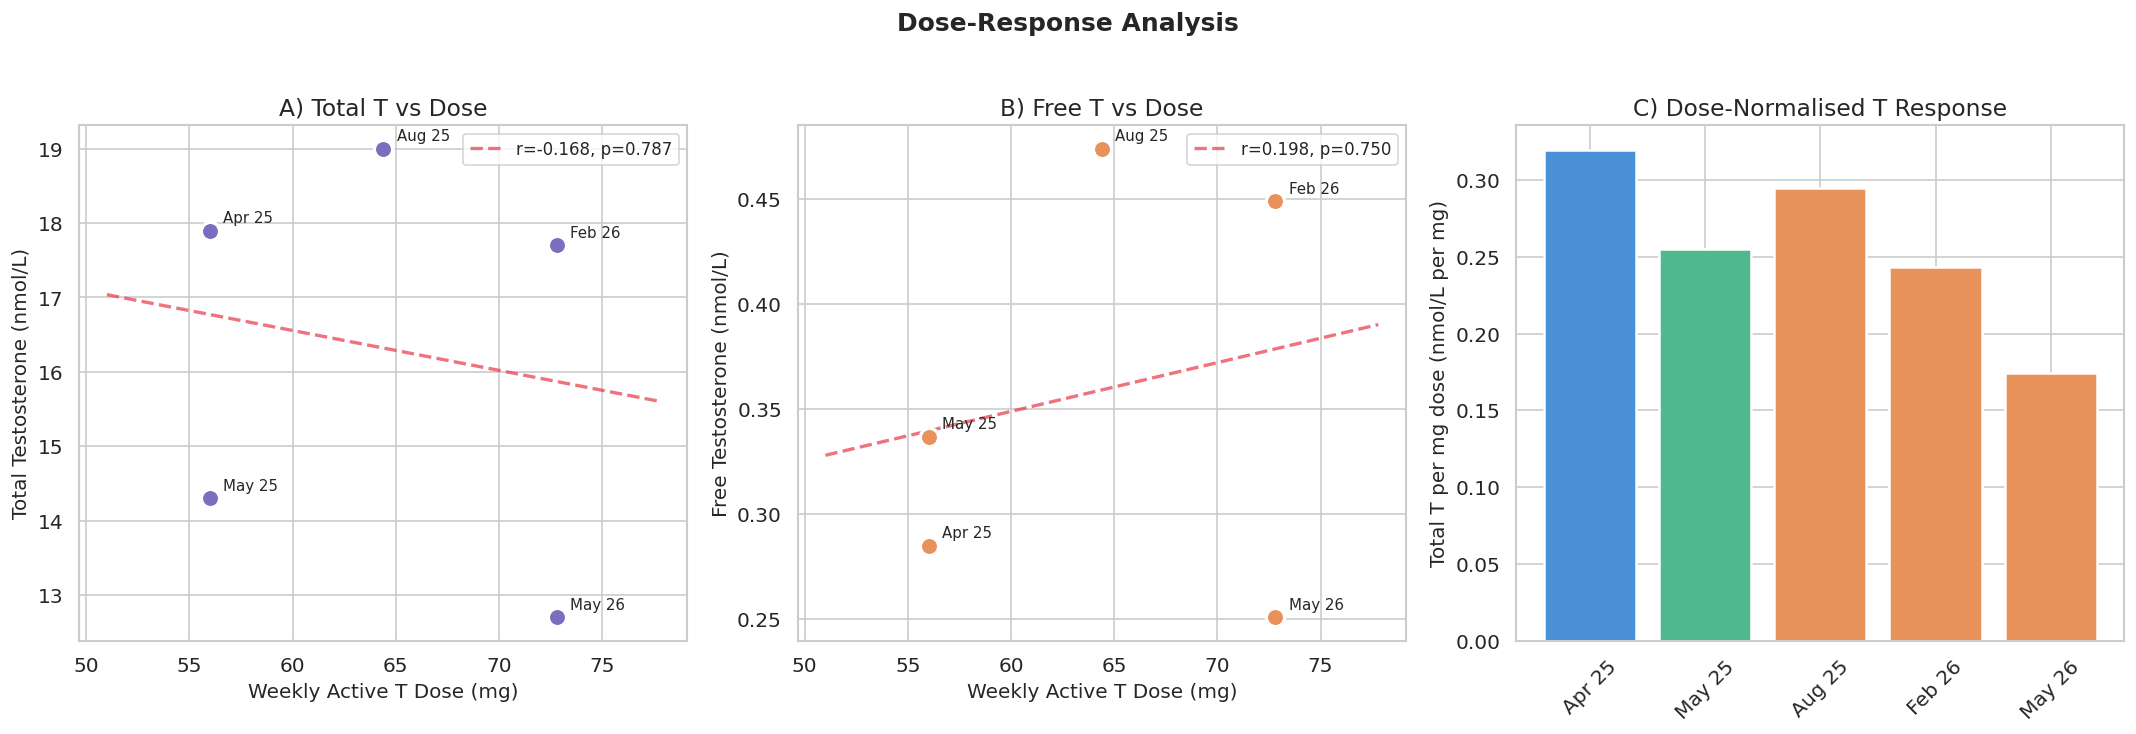

--- Dose-Response Summary ---
Dose range: 56 - 73 mg active T/week
Total T range: 12.7 - 19.0 nmol/L
Dose-normalised T at highest dose: 0.174 nmol/mg (lowest response)
Dose-normalised T at peak: 0.320 nmol/mg (best response)


In [6]:
dr = bloodwork.dropna(subset=["testosterone_nmol"]).copy()
dr = dr[dr["dose_mg_active_T"] > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
ax.scatter(dr["dose_mg_active_T"], dr["testosterone_nmol"], s=120, c=PURPLE, zorder=5, edgecolors="white", linewidth=2)
for _, row in dr.iterrows():
    ax.annotate(row["date"].strftime("%b %y"), (row["dose_mg_active_T"], row["testosterone_nmol"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
if len(dr) > 2:
    slope, intercept, r, p, se = stats.linregress(dr["dose_mg_active_T"], dr["testosterone_nmol"])
    x_line = np.linspace(dr["dose_mg_active_T"].min() - 5, dr["dose_mg_active_T"].max() + 5, 100)
    ax.plot(x_line, slope * x_line + intercept, "--", color=RED, alpha=0.7, label=f"r={r:.3f}, p={p:.3f}")
    ax.legend(fontsize=10)
ax.set_xlabel("Weekly Active T Dose (mg)")
ax.set_ylabel("Total Testosterone (nmol/L)")
ax.set_title("A) Total T vs Dose")

ax = axes[1]
ax.scatter(dr["dose_mg_active_T"], dr["free_testosterone_nmol"], s=120, c=ORANGE, zorder=5, edgecolors="white", linewidth=2)
for _, row in dr.iterrows():
    ax.annotate(row["date"].strftime("%b %y"), (row["dose_mg_active_T"], row["free_testosterone_nmol"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
if len(dr) > 2:
    slope, intercept, r, p, se = stats.linregress(dr["dose_mg_active_T"], dr["free_testosterone_nmol"])
    x_line = np.linspace(dr["dose_mg_active_T"].min() - 5, dr["dose_mg_active_T"].max() + 5, 100)
    ax.plot(x_line, slope * x_line + intercept, "--", color=RED, alpha=0.7, label=f"r={r:.3f}, p={p:.3f}")
    ax.legend(fontsize=10)
ax.set_xlabel("Weekly Active T Dose (mg)")
ax.set_ylabel("Free Testosterone (nmol/L)")
ax.set_title("B) Free T vs Dose")

dr["t_per_mg"] = dr["testosterone_nmol"] / dr["dose_mg_active_T"]
ax = axes[2]
colours = [BLUE, GREEN, ORANGE, ORANGE, ORANGE][:len(dr)]
ax.bar(dr["date"].dt.strftime("%b %y"), dr["t_per_mg"], color=colours, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Total T per mg dose (nmol/L per mg)")
ax.set_title("C) Dose-Normalised T Response")
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Dose-Response Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("--- Dose-Response Summary ---")
print(f"Dose range: {dr['dose_mg_active_T'].min():.0f} - {dr['dose_mg_active_T'].max():.0f} mg active T/week")
print(f"Total T range: {dr['testosterone_nmol'].min():.1f} - {dr['testosterone_nmol'].max():.1f} nmol/L")
print(f"Dose-normalised T at highest dose: {dr['t_per_mg'].iloc[-1]:.3f} nmol/mg (lowest response)")
print(f"Dose-normalised T at peak: {dr['t_per_mg'].max():.3f} nmol/mg (best response)")

---
## 4. SHBG Dynamics & Free Testosterone Fraction
**Free Androgen Index (FAI)** = (Total T / SHBG) x 100 — a clinical proxy for androgenic status (Vermeulen et al., 1999).

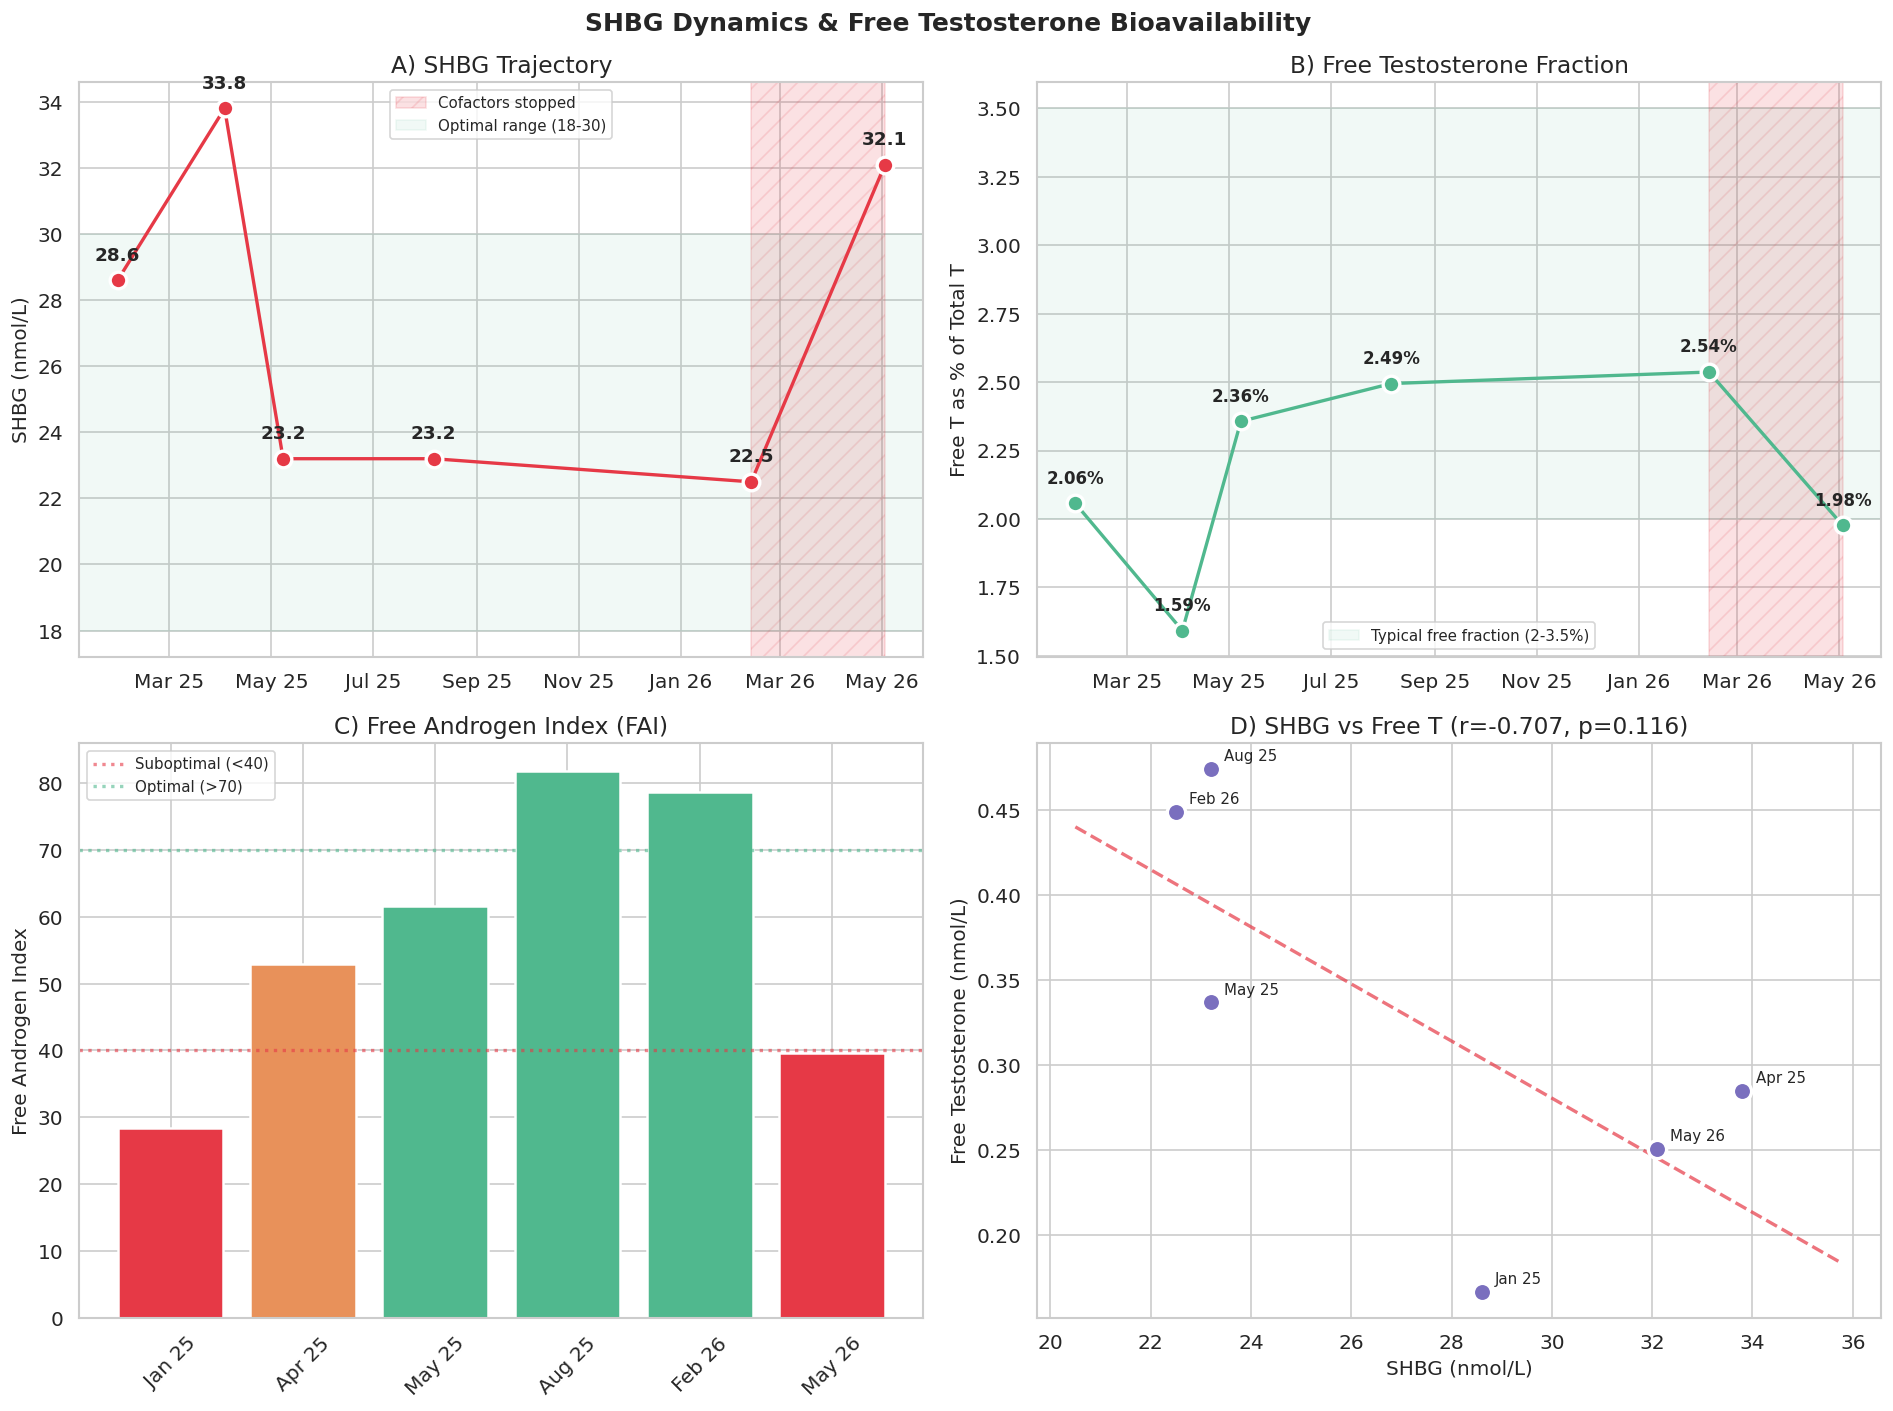

--- SHBG Change: Cofactors On vs Off ---
SHBG:   22.5 -> 32.1 nmol/L  (+42.7%)
Free T: 0.449 -> 0.251 nmol/L  (-44.1%)
FAI:    78.7 -> 39.6  (-49.7%)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
shbg = bloodwork.dropna(subset=["shbg_nmol"])
ax.plot(shbg["date"], shbg["shbg_nmol"], "o-", color=RED, markersize=10, linewidth=2, markeredgecolor="white", markeredgewidth=2)
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.15, color=RED, hatch="//", label="Cofactors stopped")
for _, row in shbg.iterrows():
    ax.annotate(f'{row["shbg_nmol"]:.1f}', (row["date"], row["shbg_nmol"]),
                textcoords="offset points", xytext=(0, 12), fontsize=11, fontweight="bold", ha="center")
ax.axhspan(18, 30, alpha=0.08, color=GREEN, label="Optimal range (18-30)")
ax.set_ylabel("SHBG (nmol/L)")
ax.set_title("A) SHBG Trajectory")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[0, 1]
ft_pct = bloodwork.dropna(subset=["free_t_pct"])
ax.plot(ft_pct["date"], ft_pct["free_t_pct"], "o-", color=GREEN, markersize=10, linewidth=2, markeredgecolor="white", markeredgewidth=2)
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.15, color=RED, hatch="//")
for _, row in ft_pct.iterrows():
    ax.annotate(f'{row["free_t_pct"]:.2f}%', (row["date"], row["free_t_pct"]),
                textcoords="offset points", xytext=(0, 12), fontsize=10, fontweight="bold", ha="center")
ax.axhspan(2.0, 3.5, alpha=0.08, color=GREEN, label="Typical free fraction (2-3.5%)")
ax.set_ylabel("Free T as % of Total T")
ax.set_title("B) Free Testosterone Fraction")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[1, 0]
fai = bloodwork.dropna(subset=["free_androgen_index"])
colours = [RED if v < 40 else (ORANGE if v < 60 else GREEN) for v in fai["free_androgen_index"]]
ax.bar(fai["date"].dt.strftime("%b %y"), fai["free_androgen_index"], color=colours, edgecolor="white", linewidth=1.5)
ax.axhline(y=40, color=RED, linestyle=":", alpha=0.6, label="Suboptimal (<40)")
ax.axhline(y=70, color=GREEN, linestyle=":", alpha=0.6, label="Optimal (>70)")
ax.set_ylabel("Free Androgen Index")
ax.set_title("C) Free Androgen Index (FAI)")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 1]
valid = bloodwork.dropna(subset=["shbg_nmol", "free_testosterone_nmol"])
ax.scatter(valid["shbg_nmol"], valid["free_testosterone_nmol"], s=120, c=PURPLE, zorder=5, edgecolors="white", linewidth=2)
for _, row in valid.iterrows():
    ax.annotate(row["date"].strftime("%b %y"), (row["shbg_nmol"], row["free_testosterone_nmol"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
if len(valid) > 2:
    r, p = pearsonr(valid["shbg_nmol"], valid["free_testosterone_nmol"])
    slope, intercept, _, _, _ = stats.linregress(valid["shbg_nmol"], valid["free_testosterone_nmol"])
    x_line = np.linspace(valid["shbg_nmol"].min() - 2, valid["shbg_nmol"].max() + 2, 100)
    ax.plot(x_line, slope * x_line + intercept, "--", color=RED, alpha=0.7)
    ax.set_title(f"D) SHBG vs Free T (r={r:.3f}, p={p:.3f})")
ax.set_xlabel("SHBG (nmol/L)")
ax.set_ylabel("Free Testosterone (nmol/L)")

plt.suptitle("SHBG Dynamics & Free Testosterone Bioavailability", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

last_on = bloodwork[bloodwork["date"] == "2026-02-12"].iloc[0]
first_off = bloodwork[bloodwork["date"] == "2026-05-03"].iloc[0]
print("--- SHBG Change: Cofactors On vs Off ---")
print(f"SHBG:   {last_on['shbg_nmol']:.1f} -> {first_off['shbg_nmol']:.1f} nmol/L  ({((first_off['shbg_nmol']-last_on['shbg_nmol'])/last_on['shbg_nmol'])*100:+.1f}%)")
print(f"Free T: {last_on['free_testosterone_nmol']:.3f} -> {first_off['free_testosterone_nmol']:.3f} nmol/L  ({((first_off['free_testosterone_nmol']-last_on['free_testosterone_nmol'])/last_on['free_testosterone_nmol'])*100:+.1f}%)")
print(f"FAI:    {last_on['free_androgen_index']:.1f} -> {first_off['free_androgen_index']:.1f}  ({((first_off['free_androgen_index']-last_on['free_androgen_index'])/last_on['free_androgen_index'])*100:+.1f}%)")

---
## 5. Cofactor Impact Analysis
Five supplements stopped between Feb-May 2026:
1. **Boron** (10mg/day) — Direct SHBG suppressor
2. **Zinc Picolinate** — Aromatase inhibition, SHBG modulation
3. **Magnesium Glycinate** (400mg/day) — Reduces SHBG binding affinity
4. **Selenium** (100-200mcg/day) — Thyroid cofactor (T4->T3), indirect SHBG
5. **P5P** (50mg/day) — Hormone metabolism cofactor

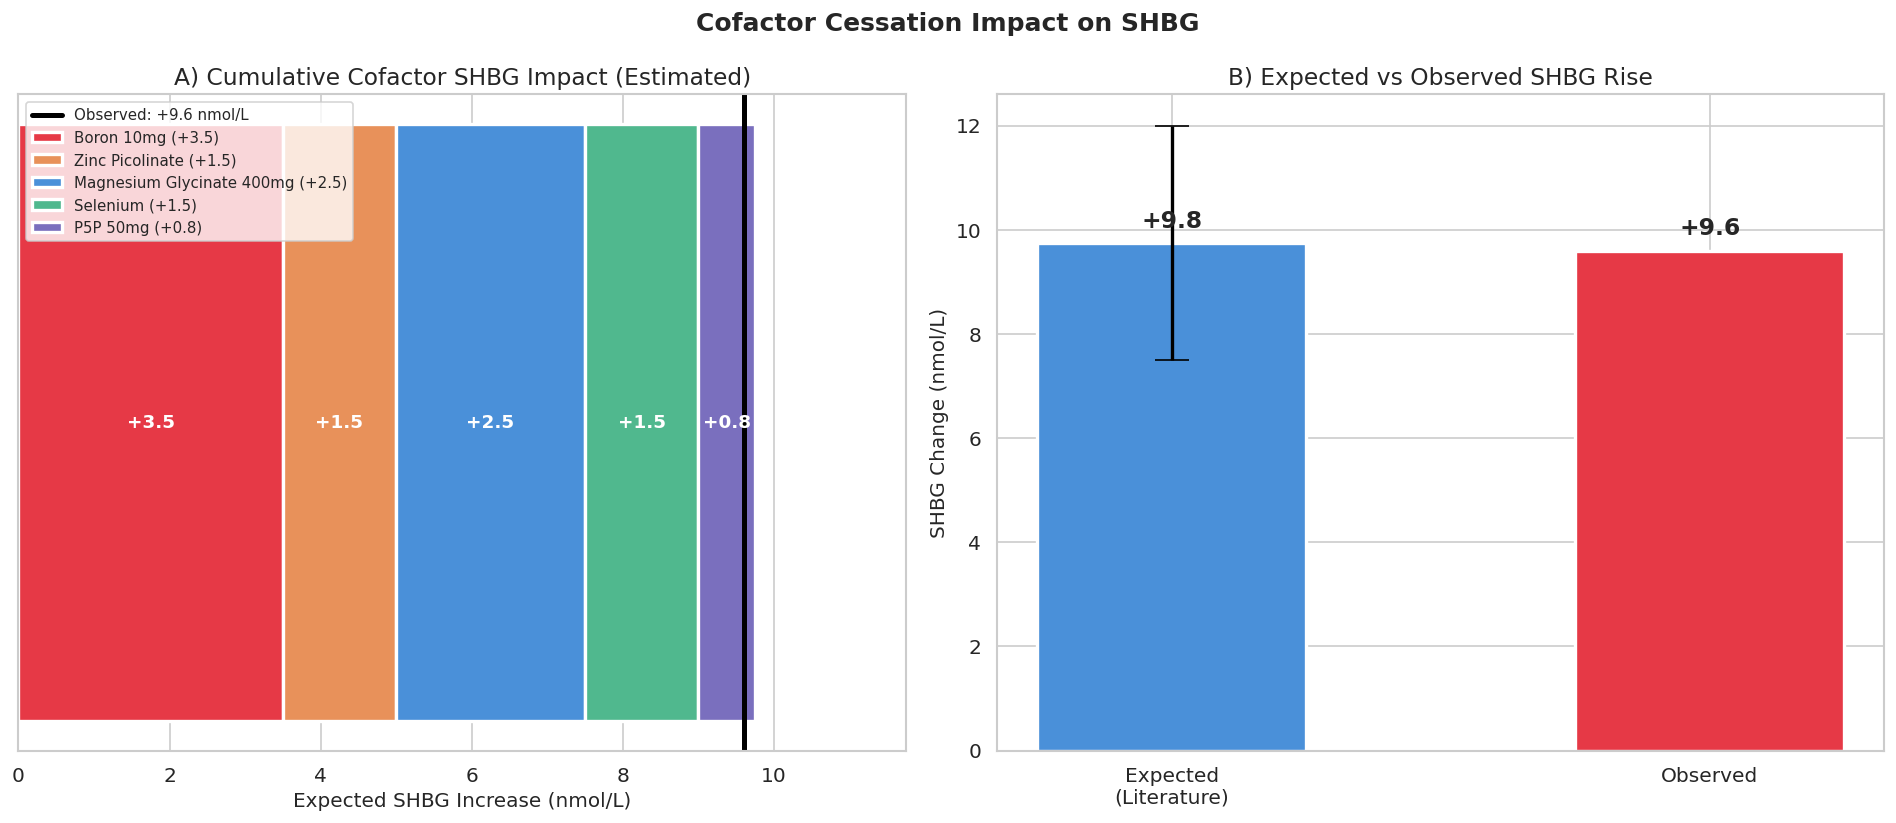

--- Cofactor SHBG Impact Summary ---
Expected range:  +7.5 to +12.0 nmol/L
Expected median: +9.8 nmol/L
Observed:        +9.6 nmol/L
Observed change falls WITHIN expected range from literature.


In [8]:
cofactors = pd.DataFrame({
    "Supplement": ["Boron 10mg", "Zinc Picolinate", "Magnesium Glycinate 400mg", "Selenium", "P5P 50mg"],
    "SHBG_impact_low": [3.0, 1.0, 2.0, 1.0, 0.5],
    "SHBG_impact_high": [4.0, 2.0, 3.0, 2.0, 1.0],
    "Mechanism": ["Direct SHBG suppression (Naghii 2011)", "Aromatase/SHBG cofactor (Prasad 1996)",
                  "SHBG binding affinity (Excelmyer 2021)", "Thyroid-SHBG pathway", "Hormone metabolism (B6)"],
    "Colour": [RED, ORANGE, BLUE, GREEN, PURPLE]
})
cofactors["SHBG_impact_mid"] = (cofactors["SHBG_impact_low"] + cofactors["SHBG_impact_high"]) / 2
observed_shbg_change = first_off["shbg_nmol"] - last_on["shbg_nmol"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
cumulative = 0
for _, row in cofactors.iterrows():
    ax.barh(0, row["SHBG_impact_mid"], left=cumulative, height=0.5,
            color=row["Colour"], edgecolor="white", linewidth=2,
            label=f'{row["Supplement"]} (+{row["SHBG_impact_mid"]:.1f})')
    ax.text(cumulative + row["SHBG_impact_mid"] / 2, 0, f'+{row["SHBG_impact_mid"]:.1f}',
            ha="center", va="center", fontsize=11, fontweight="bold", color="white")
    cumulative += row["SHBG_impact_mid"]

ax.axvline(x=observed_shbg_change, color="black", linewidth=3, linestyle="-",
           label=f"Observed: +{observed_shbg_change:.1f} nmol/L")
ax.set_xlabel("Expected SHBG Increase (nmol/L)")
ax.set_title("A) Cumulative Cofactor SHBG Impact (Estimated)")
ax.set_yticks([])
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, max(cumulative, observed_shbg_change) + 2)

ax = axes[1]
expected_low = cofactors["SHBG_impact_low"].sum()
expected_high = cofactors["SHBG_impact_high"].sum()
expected_mid = cofactors["SHBG_impact_mid"].sum()
bars = ax.bar(["Expected\n(Literature)", "Observed"], [expected_mid, observed_shbg_change],
              color=[BLUE, RED], edgecolor="white", linewidth=2, width=0.5)
ax.errorbar(0, expected_mid, yerr=[[expected_mid - expected_low], [expected_high - expected_mid]],
            fmt="none", ecolor="black", capsize=10, linewidth=2)
for bar, val in zip(bars, [expected_mid, observed_shbg_change]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"+{val:.1f}", ha="center", fontsize=14, fontweight="bold")
ax.set_ylabel("SHBG Change (nmol/L)")
ax.set_title("B) Expected vs Observed SHBG Rise")

plt.suptitle("Cofactor Cessation Impact on SHBG", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("--- Cofactor SHBG Impact Summary ---")
print(f"Expected range:  +{expected_low:.1f} to +{expected_high:.1f} nmol/L")
print(f"Expected median: +{expected_mid:.1f} nmol/L")
print(f"Observed:        +{observed_shbg_change:.1f} nmol/L")
if expected_low <= observed_shbg_change <= expected_high:
    print("Observed change falls WITHIN expected range from literature.")

---
## 6. Training Load Analysis

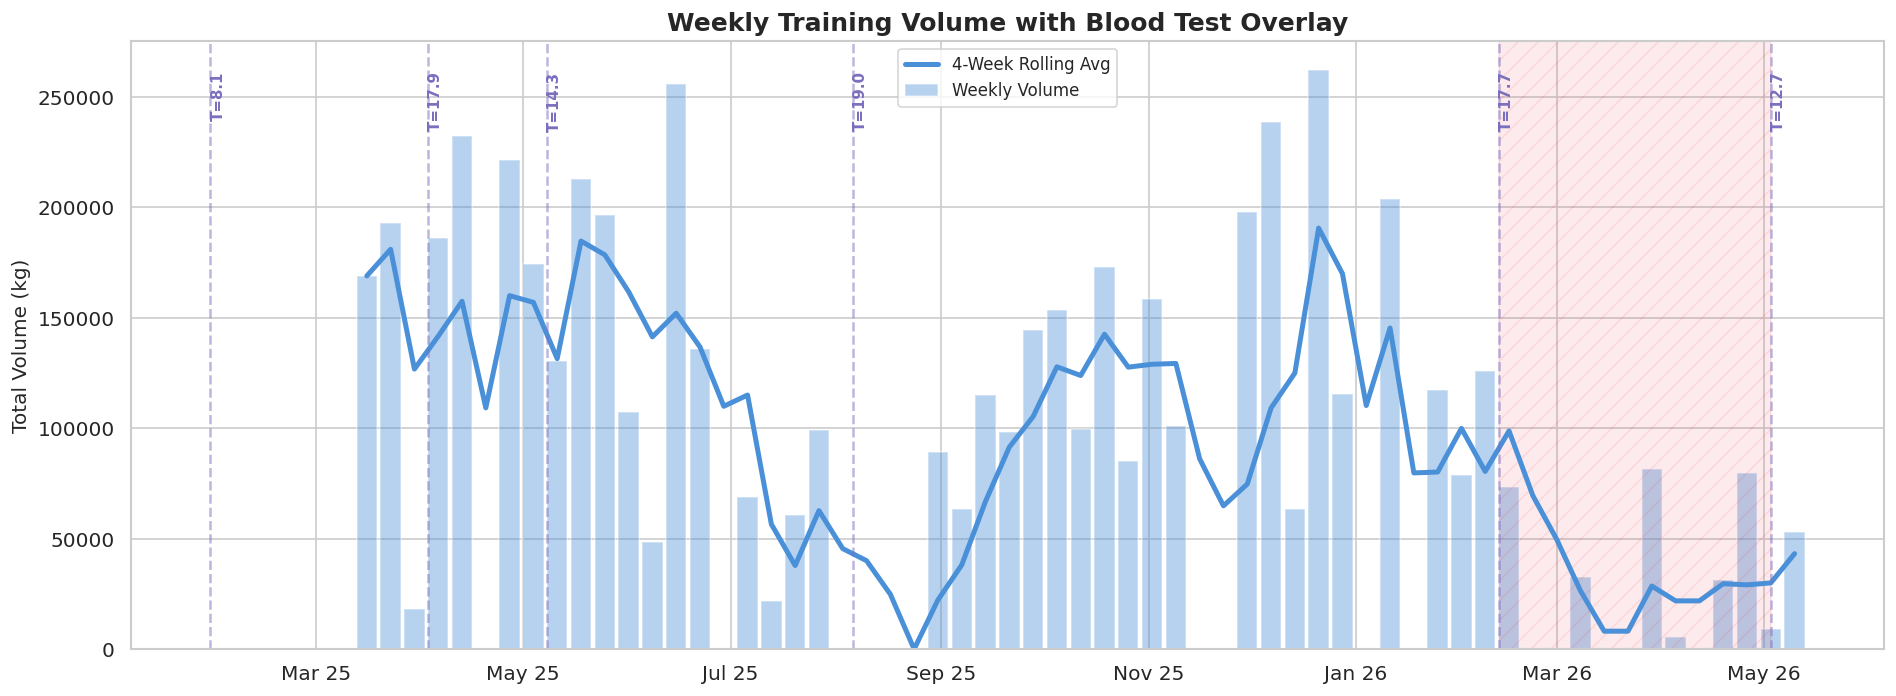

--- 14-Day Training Volume Around Blood Draws ---
  2025-01-29 (T=8.1): avg daily vol=0kg, sessions=0/14d
  2025-04-03 (T=17.9): avg daily vol=37,073kg, sessions=6/14d
  2025-05-08 (T=14.3): avg daily vol=37,250kg, sessions=9/14d
  2025-08-06 (T=19.0): avg daily vol=32,934kg, sessions=2/14d
  2026-02-12 (T=17.7): avg daily vol=45,224kg, sessions=5/14d
  2026-05-03 (T=12.7): avg daily vol=14,812kg, sessions=6/14d


In [9]:
daily_volume = workouts.groupby("day").agg(
    total_volume=pd.NamedAgg(column="volume", aggfunc="sum"),
    n_exercises=pd.NamedAgg(column="exercise", aggfunc="nunique"),
    n_sets=pd.NamedAgg(column="volume", aggfunc="count"),
).reset_index()
daily_volume.set_index("day", inplace=True)
weekly_volume = daily_volume["total_volume"].resample("W").sum().reset_index()
weekly_volume.columns = ["week", "volume"]
weekly_volume["rolling_4wk"] = weekly_volume["volume"].rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(weekly_volume["week"], weekly_volume["volume"], width=6, color=BLUE, alpha=0.4, label="Weekly Volume")
ax.plot(weekly_volume["week"], weekly_volume["rolling_4wk"], color=BLUE, linewidth=3, label="4-Week Rolling Avg")
for _, row in bt.iterrows():
    ax.axvline(x=row["date"], color=PURPLE, linestyle="--", alpha=0.5, linewidth=1.5)
    ax.text(row["date"], ax.get_ylim()[1] * 0.95, f'T={row["testosterone_nmol"]:.1f}',
            rotation=90, va="top", fontsize=9, color=PURPLE, fontweight="bold")
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Total Volume (kg)")
ax.set_title("Weekly Training Volume with Blood Test Overlay", fontsize=15, fontweight="bold")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.tight_layout()
plt.show()

print("--- 14-Day Training Volume Around Blood Draws ---")
for _, row in bt.iterrows():
    window_start = row["date"] - pd.Timedelta(days=14)
    window_end = row["date"]
    mask = (daily_volume.index >= window_start) & (daily_volume.index <= window_end)
    window_vol = daily_volume.loc[mask, "total_volume"]
    avg_daily = window_vol.mean() if len(window_vol) > 0 else 0
    n_sessions = len(window_vol[window_vol > 0])
    print(f"  {row['date'].strftime('%Y-%m-%d')} (T={row['testosterone_nmol']:.1f}): avg daily vol={avg_daily:,.0f}kg, sessions={n_sessions}/14d")

---
## 7. Recovery & Physiological Stress

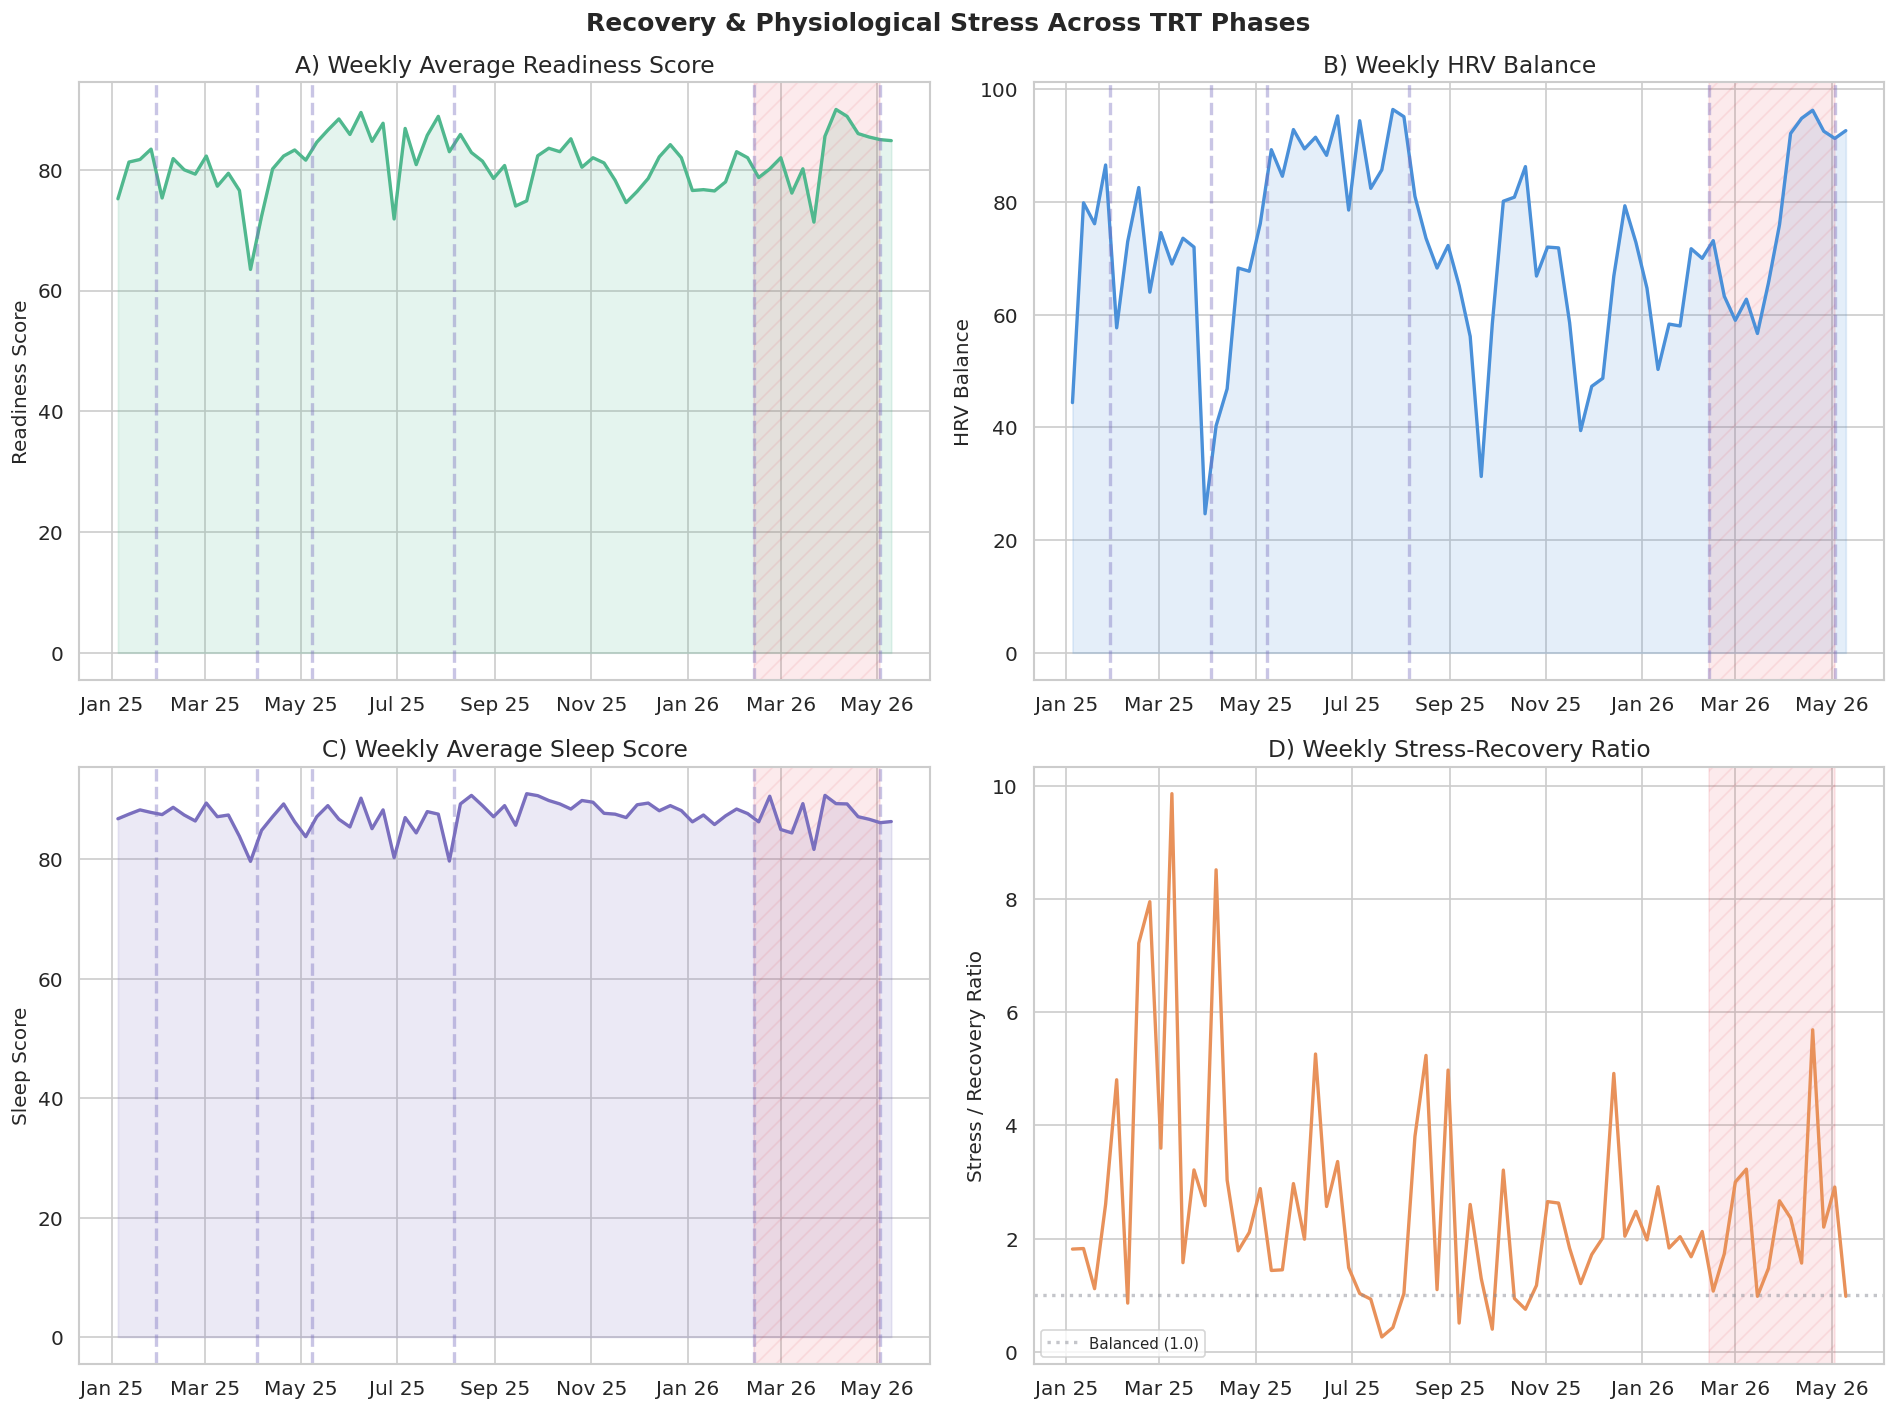

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
weekly_readiness = readiness.set_index("day")["score"].resample("W").mean().reset_index()
ax.plot(weekly_readiness["day"], weekly_readiness["score"], color=GREEN, linewidth=2)
ax.fill_between(weekly_readiness["day"], weekly_readiness["score"], alpha=0.15, color=GREEN)
for _, row in bt.iterrows():
    ax.axvline(x=row["date"], color=PURPLE, linestyle="--", alpha=0.4)
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Readiness Score")
ax.set_title("A) Weekly Average Readiness Score")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[0, 1]
hrv_col = "contributors.hrv_balance"
if hrv_col in readiness.columns:
    weekly_hrv = readiness.set_index("day")[hrv_col].resample("W").mean().reset_index()
    ax.plot(weekly_hrv["day"], weekly_hrv[hrv_col], color=BLUE, linewidth=2)
    ax.fill_between(weekly_hrv["day"], weekly_hrv[hrv_col], alpha=0.15, color=BLUE)
    for _, row in bt.iterrows():
        ax.axvline(x=row["date"], color=PURPLE, linestyle="--", alpha=0.4)
    ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("HRV Balance")
ax.set_title("B) Weekly HRV Balance")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[1, 0]
weekly_sleep = sleep.set_index("day")["score"].resample("W").mean().reset_index()
ax.plot(weekly_sleep["day"], weekly_sleep["score"], color=PURPLE, linewidth=2)
ax.fill_between(weekly_sleep["day"], weekly_sleep["score"], alpha=0.15, color=PURPLE)
for _, row in bt.iterrows():
    ax.axvline(x=row["date"], color=PURPLE, linestyle="--", alpha=0.4)
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Sleep Score")
ax.set_title("C) Weekly Average Sleep Score")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[1, 1]
stress_valid = stress.dropna(subset=["stress_high", "recovery_high"]).copy()
stress_valid["sr_ratio"] = stress_valid["stress_high"] / stress_valid["recovery_high"].replace(0, np.nan)
weekly_sr = stress_valid.set_index("day")["sr_ratio"].resample("W").mean().reset_index()
ax.plot(weekly_sr["day"], weekly_sr["sr_ratio"], color=ORANGE, linewidth=2)
ax.axhline(y=1.0, color=GREY, linestyle=":", alpha=0.5, label="Balanced (1.0)")
ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Stress / Recovery Ratio")
ax.set_title("D) Weekly Stress-Recovery Ratio")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

plt.suptitle("Recovery & Physiological Stress Across TRT Phases", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Nutrition & Body Composition

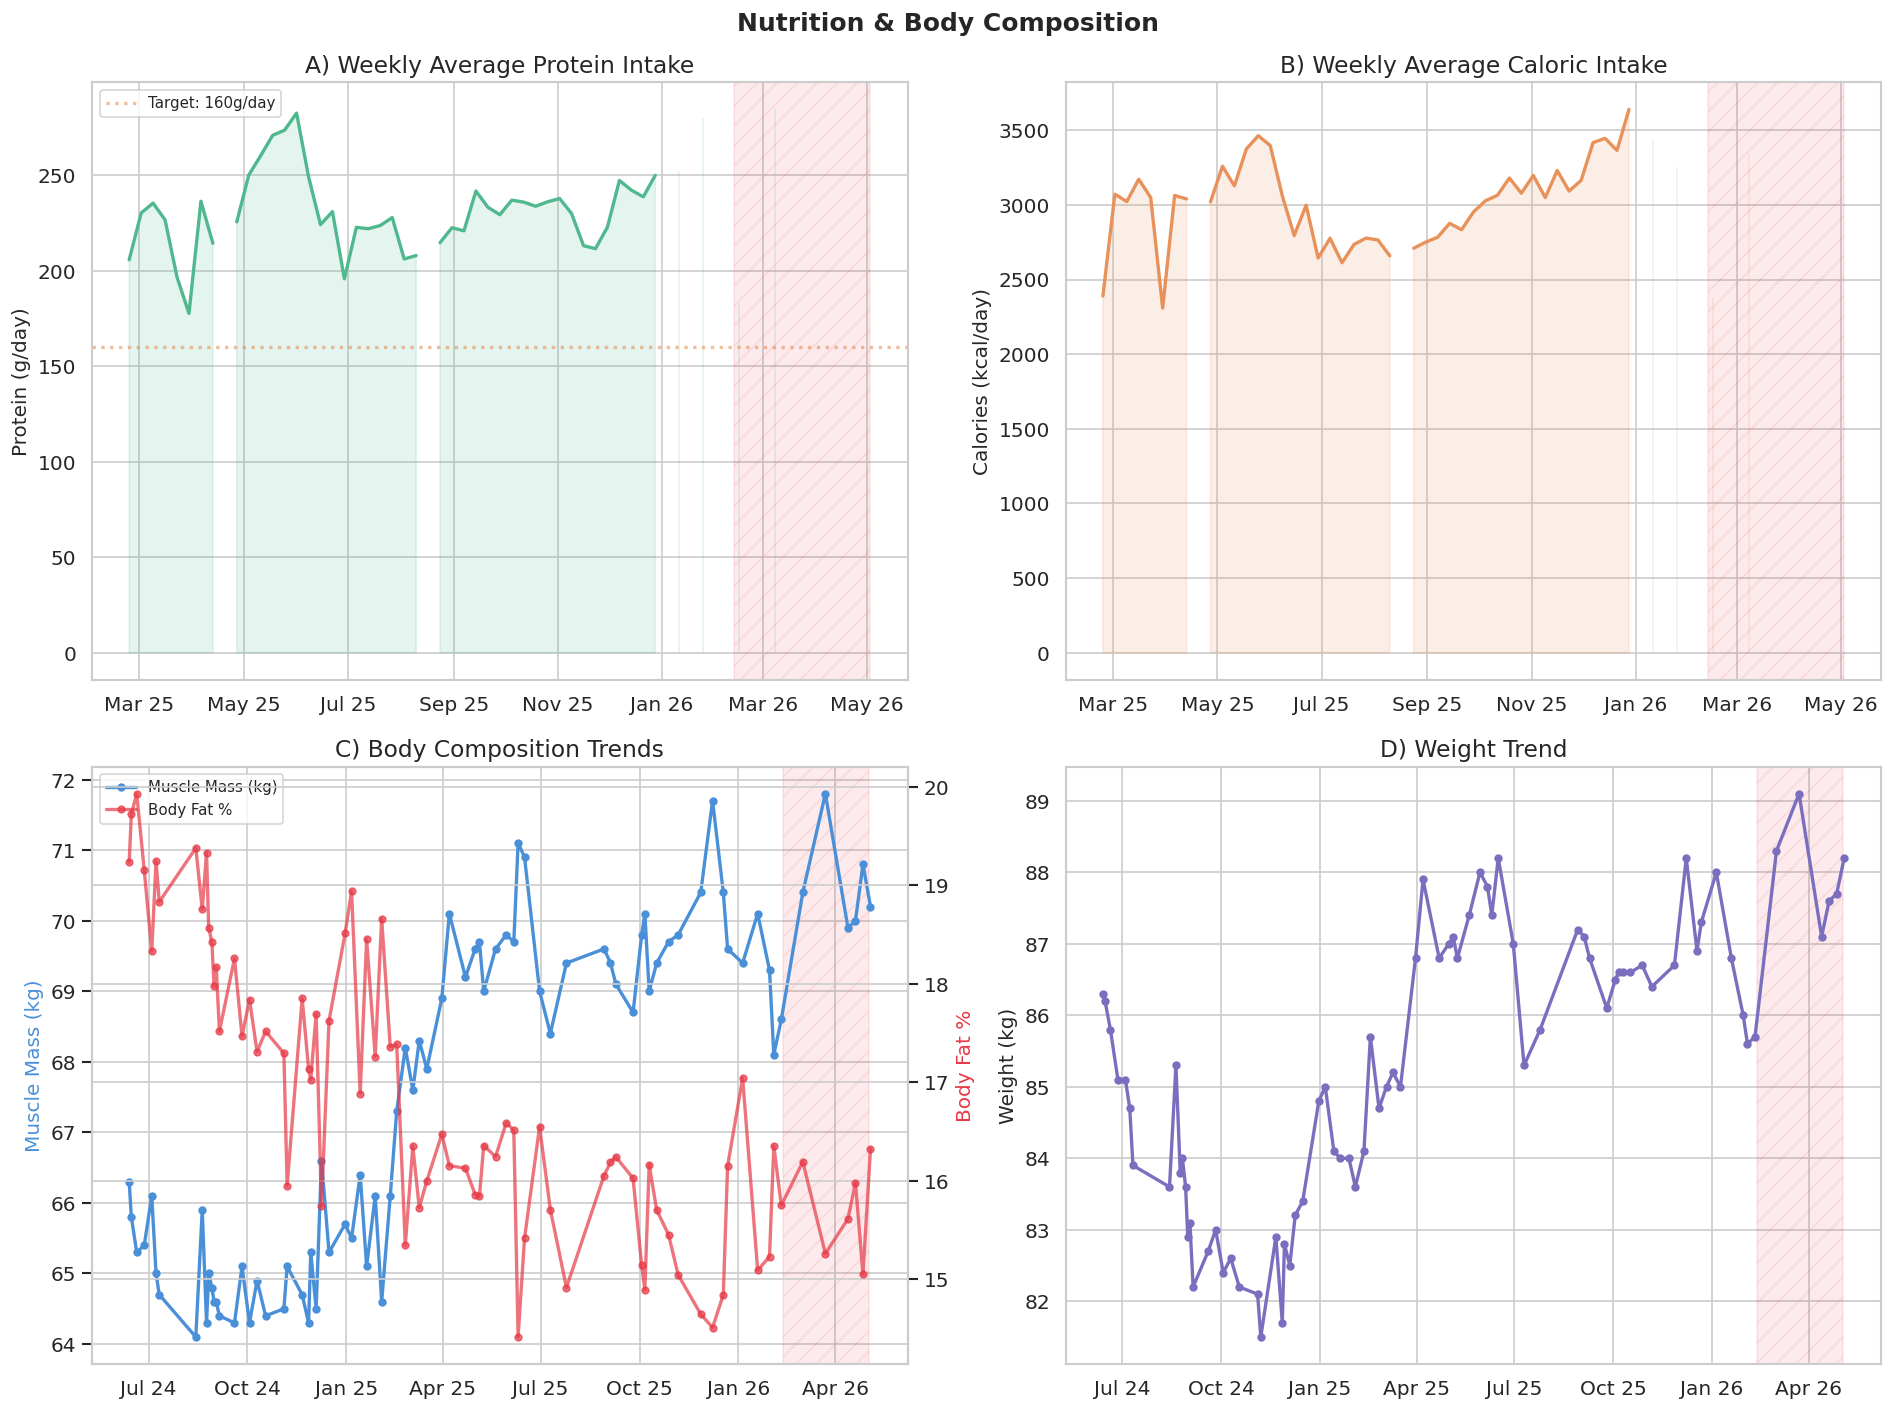

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
if len(nutrition) > 0:
    wp = nutrition.set_index("date")["protein"].resample("W").mean().reset_index()
    ax.plot(wp["date"], wp["protein"], color=GREEN, linewidth=2)
    ax.fill_between(wp["date"], wp["protein"], alpha=0.15, color=GREEN)
    ax.axhline(y=160, color=ORANGE, linestyle=":", alpha=0.6, label="Target: 160g/day")
    ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
    ax.legend(fontsize=9)
ax.set_ylabel("Protein (g/day)")
ax.set_title("A) Weekly Average Protein Intake")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[0, 1]
if len(nutrition) > 0:
    wc = nutrition.set_index("date")["calories"].resample("W").mean().reset_index()
    ax.plot(wc["date"], wc["calories"], color=ORANGE, linewidth=2)
    ax.fill_between(wc["date"], wc["calories"], alpha=0.15, color=ORANGE)
    ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Calories (kcal/day)")
ax.set_title("B) Weekly Average Caloric Intake")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[1, 0]
if len(body_comp) > 0 and "muscle_mass_kg" in body_comp.columns:
    bc = body_comp.dropna(subset=["muscle_mass_kg"])
    ax.plot(bc["date"], bc["muscle_mass_kg"], "o-", color=BLUE, markersize=4, label="Muscle Mass (kg)")
    ax2c = ax.twinx()
    bc_fat = body_comp.dropna(subset=["body_fat_pct"])
    ax2c.plot(bc_fat["date"], bc_fat["body_fat_pct"], "o-", color=RED, markersize=4, alpha=0.7, label="Body Fat %")
    ax2c.set_ylabel("Body Fat %", color=RED)
    ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2c.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=9)
ax.set_ylabel("Muscle Mass (kg)", color=BLUE)
ax.set_title("C) Body Composition Trends")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax = axes[1, 1]
if len(body_comp) > 0:
    bc_wt = body_comp.dropna(subset=["weight_kg"])
    ax.plot(bc_wt["date"], bc_wt["weight_kg"], "o-", color=PURPLE, markersize=4, linewidth=2)
    ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
ax.set_ylabel("Weight (kg)")
ax.set_title("D) Weight Trend")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

plt.suptitle("Nutrition & Body Composition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Haematological Safety Markers

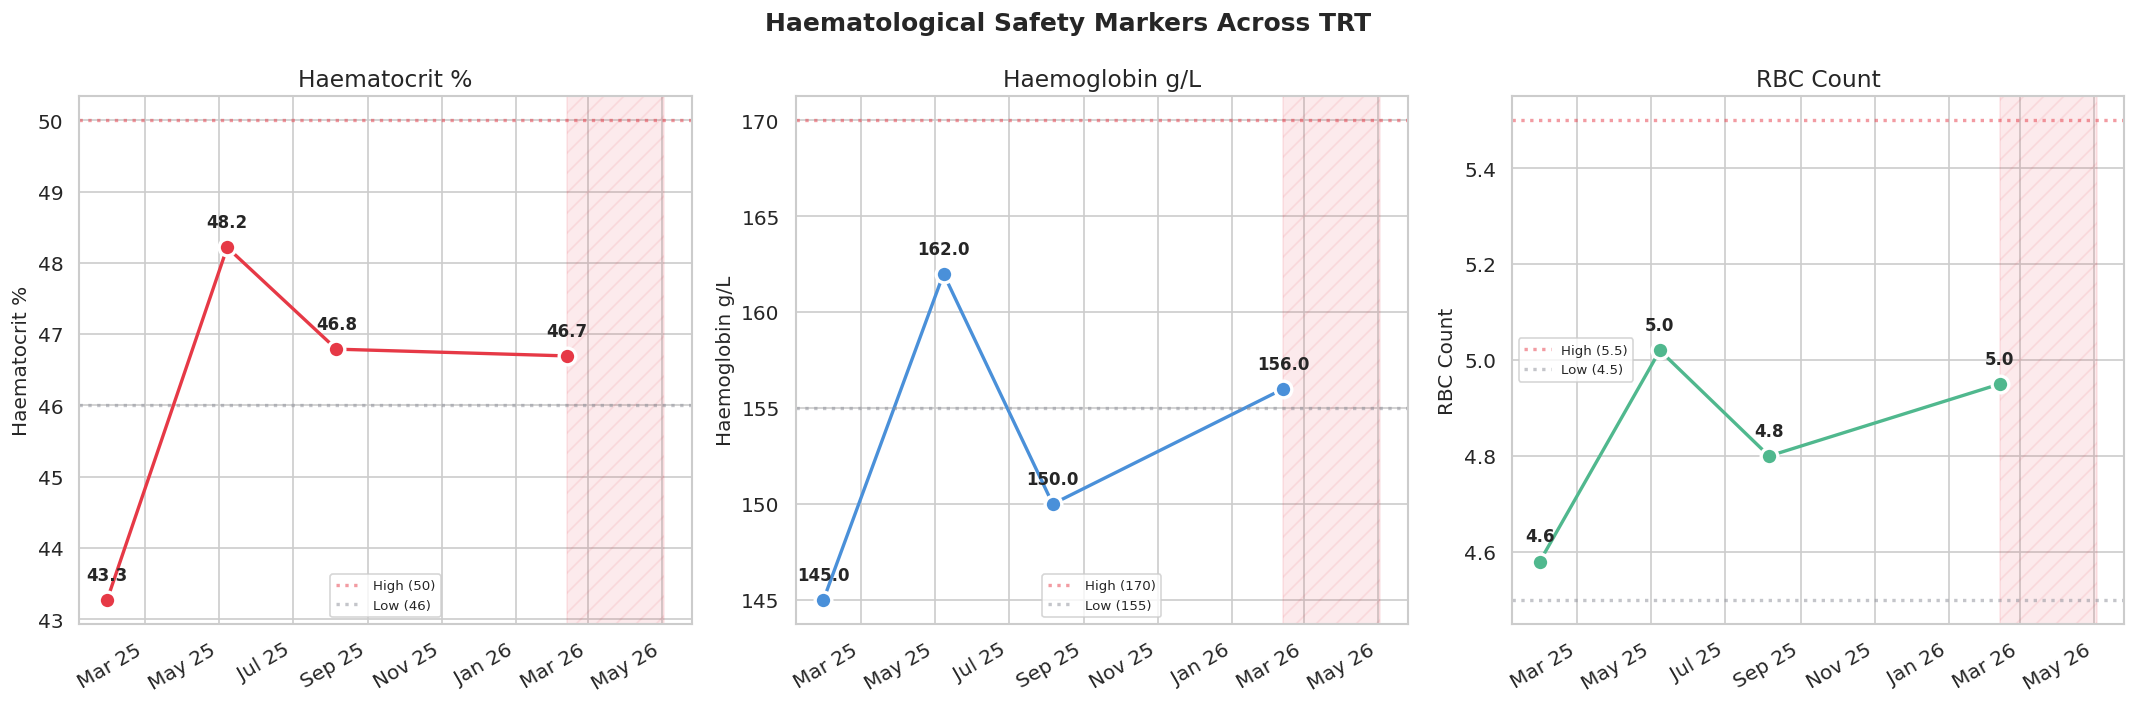

Peak haematocrit: 48.2% (threshold: 50%)
Latest haematocrit: 46.7%


In [12]:
haem = {
    "Haematocrit %": ("haematocrit_pct", RED, 50, 46),
    "Haemoglobin g/L": ("haemoglobin_g", BLUE, 170, 155),
    "RBC Count": ("rbc_count", GREEN, 5.5, 4.5),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for (title, (col, colour, hi, lo)), ax in zip(haem.items(), axes):
    valid = bloodwork.dropna(subset=[col])
    if len(valid) > 0:
        ax.plot(valid["date"], valid[col], "o-", color=colour, markersize=10, linewidth=2, markeredgecolor="white", markeredgewidth=2)
        for _, row in valid.iterrows():
            ax.annotate(f'{row[col]:.1f}', (row["date"], row[col]),
                        textcoords="offset points", xytext=(0, 12), fontsize=10, fontweight="bold", ha="center")
        ax.axhline(y=hi, color=RED, linestyle=":", alpha=0.5, label=f"High ({hi})")
        ax.axhline(y=lo, color=GREY, linestyle=":", alpha=0.5, label=f"Low ({lo})")
        ax.axvspan(COFACTOR_STOP_START, COFACTOR_STOP_END, alpha=0.1, color=RED, hatch="//")
        ax.legend(fontsize=8)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    fig.autofmt_xdate()

plt.suptitle("Haematological Safety Markers Across TRT", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

hct = bloodwork.dropna(subset=["haematocrit_pct"])
if len(hct) > 0:
    print(f"Peak haematocrit: {hct['haematocrit_pct'].max():.1f}% (threshold: 50%)")
    print(f"Latest haematocrit: {hct.iloc[-1]['haematocrit_pct']:.1f}%")

---
## 10. Multi-Marker Correlation Matrix

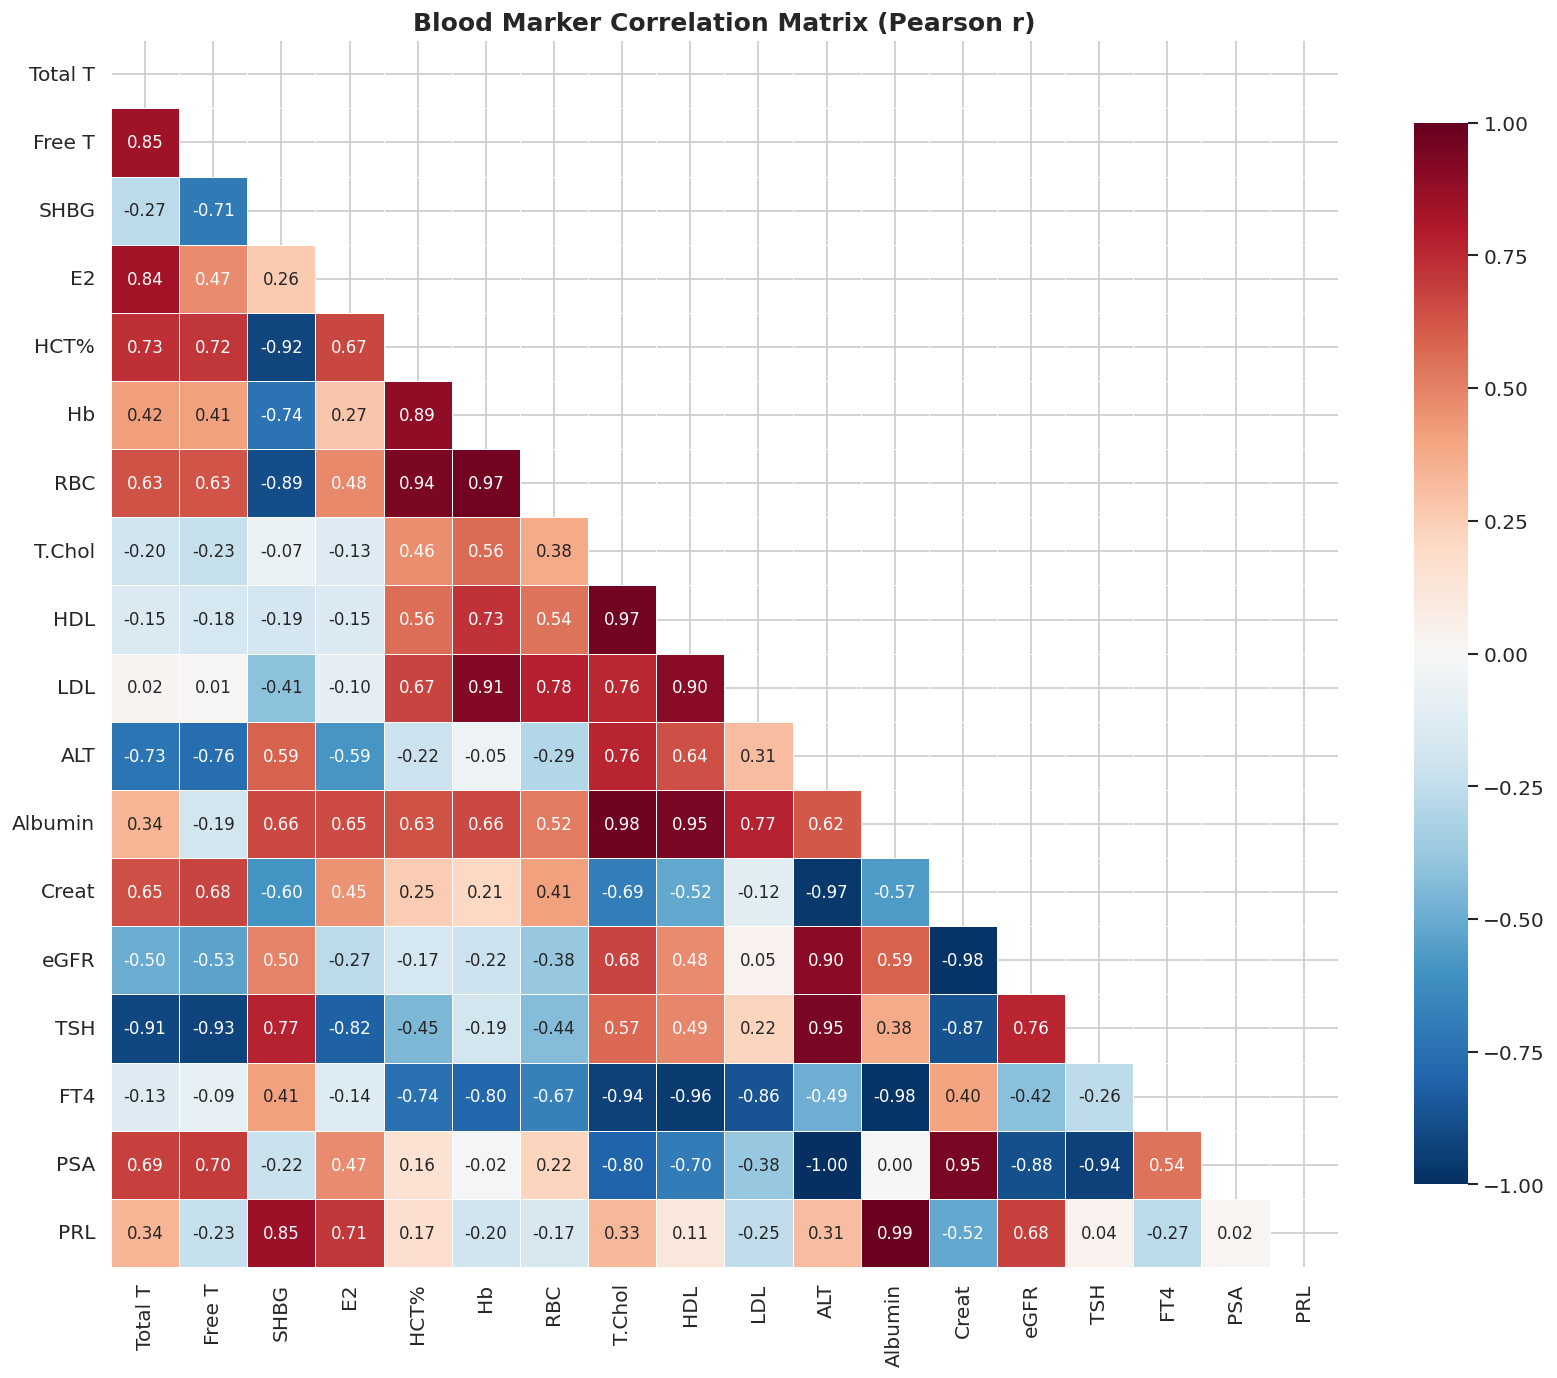

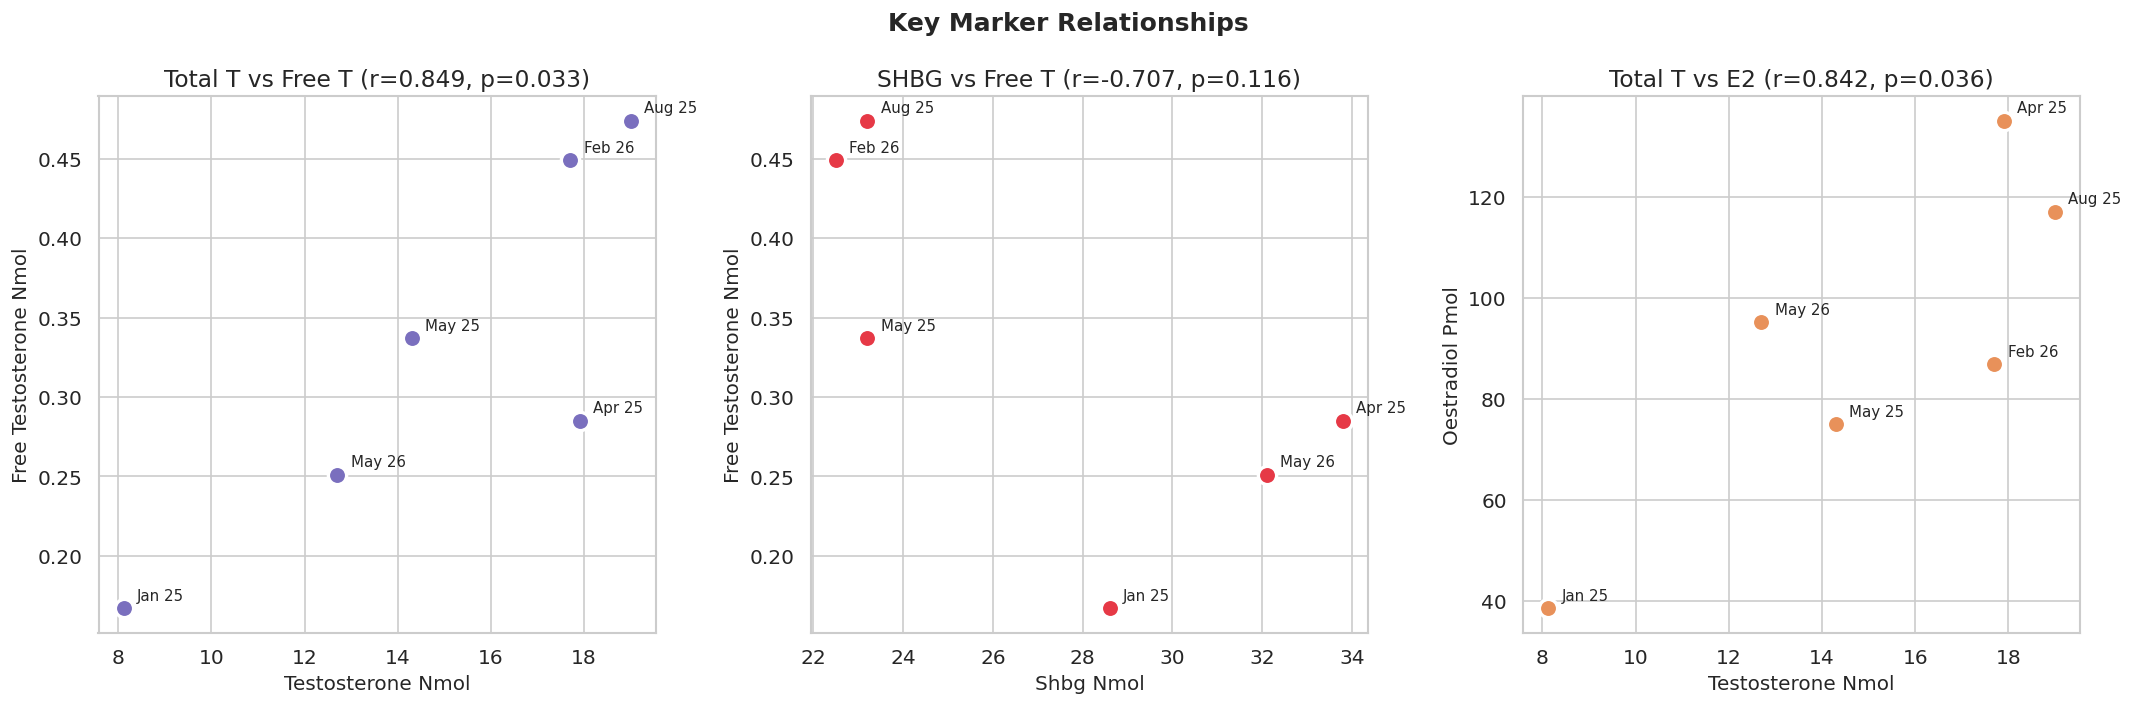

In [13]:
marker_cols = ["testosterone_nmol", "free_testosterone_nmol", "shbg_nmol", "oestradiol_pmol",
               "haematocrit_pct", "haemoglobin_g", "rbc_count",
               "total_cholesterol_mmol", "hdl_mmol", "ldl_mmol",
               "alt_u", "albumin_g", "creatinine_umol", "egfr_ml",
               "tsh_miu", "free_t4_pmol", "psa_ug", "prolactin_miu"]

available = [c for c in marker_cols if c in bloodwork.columns]
marker_data = bloodwork[available].dropna(axis=1, thresh=3)

if marker_data.shape[1] > 3:
    corr_matrix = marker_data.corr(method="pearson")
    rename = {"testosterone_nmol": "Total T", "free_testosterone_nmol": "Free T",
              "shbg_nmol": "SHBG", "oestradiol_pmol": "E2",
              "haematocrit_pct": "HCT%", "haemoglobin_g": "Hb",
              "rbc_count": "RBC", "total_cholesterol_mmol": "T.Chol",
              "hdl_mmol": "HDL", "ldl_mmol": "LDL", "alt_u": "ALT",
              "albumin_g": "Albumin", "creatinine_umol": "Creat",
              "egfr_ml": "eGFR", "tsh_miu": "TSH", "free_t4_pmol": "FT4",
              "psa_ug": "PSA", "prolactin_miu": "PRL"}
    corr_display = corr_matrix.rename(index=rename, columns=rename)
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_display, dtype=bool))
    sns.heatmap(corr_display, mask=mask, annot=True, fmt=".2f", center=0,
                cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                linewidths=0.5, cbar_kws={"shrink": 0.8}, annot_kws={"size": 10}, ax=ax)
    ax.set_title("Blood Marker Correlation Matrix (Pearson r)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Key scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [
    ("testosterone_nmol", "free_testosterone_nmol", "Total T vs Free T", PURPLE),
    ("shbg_nmol", "free_testosterone_nmol", "SHBG vs Free T", RED),
    ("testosterone_nmol", "oestradiol_pmol", "Total T vs E2", ORANGE),
]
for (x_col, y_col, title, colour), ax in zip(pairs, axes):
    v = bloodwork.dropna(subset=[x_col, y_col])
    if len(v) >= 3:
        ax.scatter(v[x_col], v[y_col], s=120, c=colour, zorder=5, edgecolors="white", linewidth=2)
        for _, row in v.iterrows():
            ax.annotate(row["date"].strftime("%b %y"), (row[x_col], row[y_col]),
                        textcoords="offset points", xytext=(8, 5), fontsize=9)
        r, p = pearsonr(v[x_col], v[y_col])
        ax.set_title(f"{title} (r={r:.3f}, p={p:.3f})")
    ax.set_xlabel(x_col.replace("_", " ").title())
    ax.set_ylabel(y_col.replace("_", " ").title())
plt.suptitle("Key Marker Relationships", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 10b. Physiological Context Around Blood Draws
14-day rolling averages of Oura metrics at each blood draw.

In [14]:
contexts = []
for _, brow in bt.iterrows():
    d = brow["date"]
    ctx = {"date": d, "testosterone_nmol": brow["testosterone_nmol"]}
    s_mask = (sleep["day"] >= d - pd.Timedelta(days=14)) & (sleep["day"] <= d)
    ctx["sleep_score"] = sleep.loc[s_mask, "score"].mean()
    r_mask = (readiness["day"] >= d - pd.Timedelta(days=14)) & (readiness["day"] <= d)
    ctx["readiness_score"] = readiness.loc[r_mask, "score"].mean()
    if "contributors.hrv_balance" in readiness.columns:
        ctx["hrv_balance"] = readiness.loc[r_mask, "contributors.hrv_balance"].mean()
    a_mask = (activity["day"] >= d - pd.Timedelta(days=14)) & (activity["day"] <= d)
    ctx["steps"] = activity.loc[a_mask, "steps"].mean()
    t_mask = (daily_volume.index >= d - pd.Timedelta(days=14)) & (daily_volume.index <= d)
    ctx["training_vol"] = daily_volume.loc[t_mask, "total_volume"].sum()
    contexts.append(ctx)

ctx_df = pd.DataFrame(contexts)
print("=== Physiological Context at Each Blood Draw (14-Day Averages) ===")
print(ctx_df.round(1).to_string(index=False))

print("\n--- Correlations with Total T ---")
phys_cols = [c for c in ctx_df.columns if c not in ["date", "testosterone_nmol"]]
for col in phys_cols:
    valid = ctx_df.dropna(subset=[col, "testosterone_nmol"])
    if len(valid) >= 4:
        r, p = pearsonr(valid[col], valid["testosterone_nmol"])
        print(f"  {col:25s}  r={r:+.3f}  p={p:.3f}  {'*' if p < 0.05 else ''}")

=== Physiological Context at Each Blood Draw (14-Day Averages) ===
      date  testosterone_nmol  sleep_score  readiness_score  hrv_balance   steps  training_vol
2025-01-29                8.1         88.8             82.8         79.4  9720.7           0.0
2025-04-03               17.9         83.1             71.0         42.6 11091.6      222440.0
2025-05-08               14.3         85.5             82.3         78.1  9349.4      335250.0
2025-08-06               19.0         85.0             86.3         93.2  7887.7       65868.0
2026-02-12               17.7         86.0             80.4         71.9  8334.5      226120.0
2026-05-03               12.7         85.9             84.9         91.9 10184.3       88869.0

--- Correlations with Total T ---
  sleep_score                r=-0.819  p=0.046  *
  readiness_score            r=-0.283  p=0.586  
  hrv_balance                r=-0.265  p=0.611  
  steps                      r=-0.328  p=0.526  
  training_vol               r=+0.43

/tmp/ipykernel_111996/964903148.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(ctx_df.round(1).to_string(index=False))


---
## 11. Statistical Summary & Hypothesis Testing

In [15]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print("\n1. DOSE-RESPONSE REGRESSION")
print("-" * 40)
dr_valid = bloodwork.dropna(subset=["testosterone_nmol"]).copy()
dr_valid = dr_valid[dr_valid["dose_mg_active_T"] > 0]
if len(dr_valid) >= 3:
    slope, intercept, r, p, se = stats.linregress(dr_valid["dose_mg_active_T"], dr_valid["testosterone_nmol"])
    print(f"  Total T = {slope:.3f} x dose + {intercept:.1f}")
    print(f"  r = {r:.3f}, R2 = {r**2:.3f}, p = {p:.3f}")
    if r < 0:
        print("  -> NEGATIVE dose-response: higher doses produced LOWER T levels.")
        print("  -> This indicates confounders (SHBG, cofactors, absorption).")

print("\n2. SHBG AS PREDICTOR OF FREE T")
print("-" * 40)
valid = bloodwork.dropna(subset=["shbg_nmol", "free_testosterone_nmol"])
if len(valid) >= 3:
    r, p = pearsonr(valid["shbg_nmol"], valid["free_testosterone_nmol"])
    print(f"  Pearson r = {r:.3f}, p = {p:.3f}")
    print(f"  R2 = {r**2:.3f} -> SHBG explains {r**2*100:.1f}% of Free T variance")
    rho, p_s = spearmanr(valid["shbg_nmol"], valid["free_testosterone_nmol"])
    print(f"  Spearman rho = {rho:.3f}, p = {p_s:.3f}")

print("\n3. MULTIPLE REGRESSION: Free T ~ Dose + SHBG")
print("-" * 40)
multi = bloodwork.dropna(subset=["free_testosterone_nmol", "shbg_nmol", "dose_mg_active_T"])
multi = multi[multi["dose_mg_active_T"] > 0]
if len(multi) >= 4:
    X = add_constant(multi[["dose_mg_active_T", "shbg_nmol"]])
    y = multi["free_testosterone_nmol"]
    model = OLS(y, X).fit()
    print(model.summary2().tables[1].to_string())
    print(f"  Adjusted R2 = {model.rsquared_adj:.3f}")

print("\n4. COFACTOR CESSATION EFFECT SIZE")
print("-" * 40)
shbg_chg = first_off["shbg_nmol"] - last_on["shbg_nmol"]
ft_chg = first_off["free_testosterone_nmol"] - last_on["free_testosterone_nmol"]
tt_chg = first_off["testosterone_nmol"] - last_on["testosterone_nmol"]
print(f"  SHBG:    {last_on['shbg_nmol']:.1f} -> {first_off['shbg_nmol']:.1f}  (delta = {shbg_chg:+.1f} nmol/L, {shbg_chg/last_on['shbg_nmol']*100:+.1f}%)")
print(f"  Free T:  {last_on['free_testosterone_nmol']:.3f} -> {first_off['free_testosterone_nmol']:.3f}  (delta = {ft_chg:+.3f} nmol/L, {ft_chg/last_on['free_testosterone_nmol']*100:+.1f}%)")
print(f"  Total T: {last_on['testosterone_nmol']:.1f} -> {first_off['testosterone_nmol']:.1f}  (delta = {tt_chg:+.1f} nmol/L, {tt_chg/last_on['testosterone_nmol']*100:+.1f}%)")

print("\n5. BSSM THERAPEUTIC TARGET ASSESSMENT")
print("-" * 40)
latest = bloodwork.iloc[-1]
print(f"  Latest Total T: {latest['testosterone_nmol']:.1f} nmol/L (BSSM target: 15-30)")
print(f"  Latest Free T:  {latest['free_testosterone_nmol']:.3f} nmol/L (target: 0.225-0.500)")
print(f"  Latest SHBG:    {latest['shbg_nmol']:.1f} nmol/L")
print(f"  Latest HCT:     {bloodwork.dropna(subset=['haematocrit_pct']).iloc[-1]['haematocrit_pct']:.1f}% (BSSM ceiling: 54%)")
if latest['testosterone_nmol'] < 15:
    deficit = (15 - latest["testosterone_nmol"]) / 15 * 100
    print(f"  -> Total T is {deficit:.0f}% below BSSM minimum trough target (15 nmol/L).")
if latest['free_testosterone_nmol'] < 0.225:
    deficit = (0.225 - latest["free_testosterone_nmol"]) / 0.225 * 100
    print(f"  -> Free T is {deficit:.0f}% below minimum target (0.225 nmol/L).")

print("\n6. DOSE TITRATION ESTIMATE (BSSM: 10-25% increments)")
print("-" * 40)
peak = bloodwork[bloodwork["date"] == "2025-08-06"].iloc[0]
peak_ratio = peak["testosterone_nmol"] / peak["dose_mg_active_T"]
current_dose = latest["dose_mg_active_T"]
# Conservative: what dose to reach 15 nmol/L (BSSM minimum) without cofactors
unsuppressed_ratio_stat = latest["testosterone_nmol"] / current_dose
dose_for_15 = 15 / unsuppressed_ratio_stat
dose_for_20 = 20 / unsuppressed_ratio_stat
dose_for_25 = 25 / unsuppressed_ratio_stat
print(f"  Current dose-response (without cofactors): {unsuppressed_ratio_stat:.3f} nmol/mg")
print(f"  Est. dose for 15 nmol/L (BSSM minimum):   ~{dose_for_15:.0f}mg active T/wk = {dose_for_15/ESTER_FACTOR:.0f}mg cypionate")
print(f"  Est. dose for 20 nmol/L (mid-range):       ~{dose_for_20:.0f}mg active T/wk = {dose_for_20/ESTER_FACTOR:.0f}mg cypionate")
print(f"  Est. dose for 25 nmol/L (upper-mid):       ~{dose_for_25:.0f}mg active T/wk = {dose_for_25/ESTER_FACTOR:.0f}mg cypionate")
print(f"\n  BSSM recommended titration: 10-25% per step, retest at 6-12 weeks")
pct_increase_needed = (dose_for_20 - current_dose) / current_dose * 100
n_steps_25 = int(np.ceil(np.log(dose_for_20 / current_dose) / np.log(1.25)))
n_steps_10 = int(np.ceil(np.log(dose_for_20 / current_dose) / np.log(1.10)))
print(f"  To reach 20 nmol/L: {pct_increase_needed:+.0f}% total increase needed")
print(f"    at 25% steps: ~{n_steps_25} titration(s), ~{n_steps_25 * 8}-{n_steps_25 * 12} weeks")
print(f"    at 10% steps: ~{n_steps_10} titration(s), ~{n_steps_10 * 8}-{n_steps_10 * 12} weeks")

STATISTICAL SUMMARY

1. DOSE-RESPONSE REGRESSION
----------------------------------------
  Total T = -0.054 x dose + 19.8
  r = -0.168, R2 = 0.028, p = 0.787
  -> NEGATIVE dose-response: higher doses produced LOWER T levels.
  -> This indicates confounders (SHBG, cofactors, absorption).

2. SHBG AS PREDICTOR OF FREE T
----------------------------------------
  Pearson r = -0.707, p = 0.116
  R2 = 0.500 -> SHBG explains 50.0% of Free T variance
  Spearman rho = -0.667, p = 0.148

3. MULTIPLE REGRESSION: Free T ~ Dose + SHBG
----------------------------------------
                     Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const             0.674306  0.364224  1.851350  0.205326 -0.892822  2.241433
dose_mg_active_T  0.001270  0.004528  0.280452  0.805478 -0.018213  0.020753
shbg_nmol        -0.014721  0.006905 -2.131992  0.166669 -0.044431  0.014988
  Adjusted R2 = 0.413

4. COFACTOR CESSATION EFFECT SIZE
----------------------------------------
  SHBG:    22.5 -> 32.1

/home/dean-harris/Projects/health-intel/.venv/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


---
## 12. Injection Frequency Pharmacokinetic Modelling
### Testosterone Cypionate: 2x/week vs 3x/week Steady-State Simulation

Testosterone Cypionate has a subcutaneous half-life of approximately **8 days** (range 6–10 days depending on injection site and individual pharmacokinetics). Using exponential decay superposition, we can model steady-state serum testosterone curves for different injection frequencies at various doses.

**Key PK parameters:**
- Half-life (t½): ~8 days subcutaneous (Kaminetsky et al., 2015)
- Steady state: reached in ~5 half-lives (~40 days)
- Peak occurs ~24-48h post-injection
- Trough occurs immediately pre-injection

**Clinical rationale for 3x/week:**
- Reduces peak/trough ratio (~1.2:1 vs ~1.4:1 for 2x/week)
- More stable serum levels reduce oestradiol spikes at peaks
- Smaller per-injection volume improves subcutaneous absorption
- Lower peak reduces haematocrit/polycythaemia risk (Bachman et al., 2014)

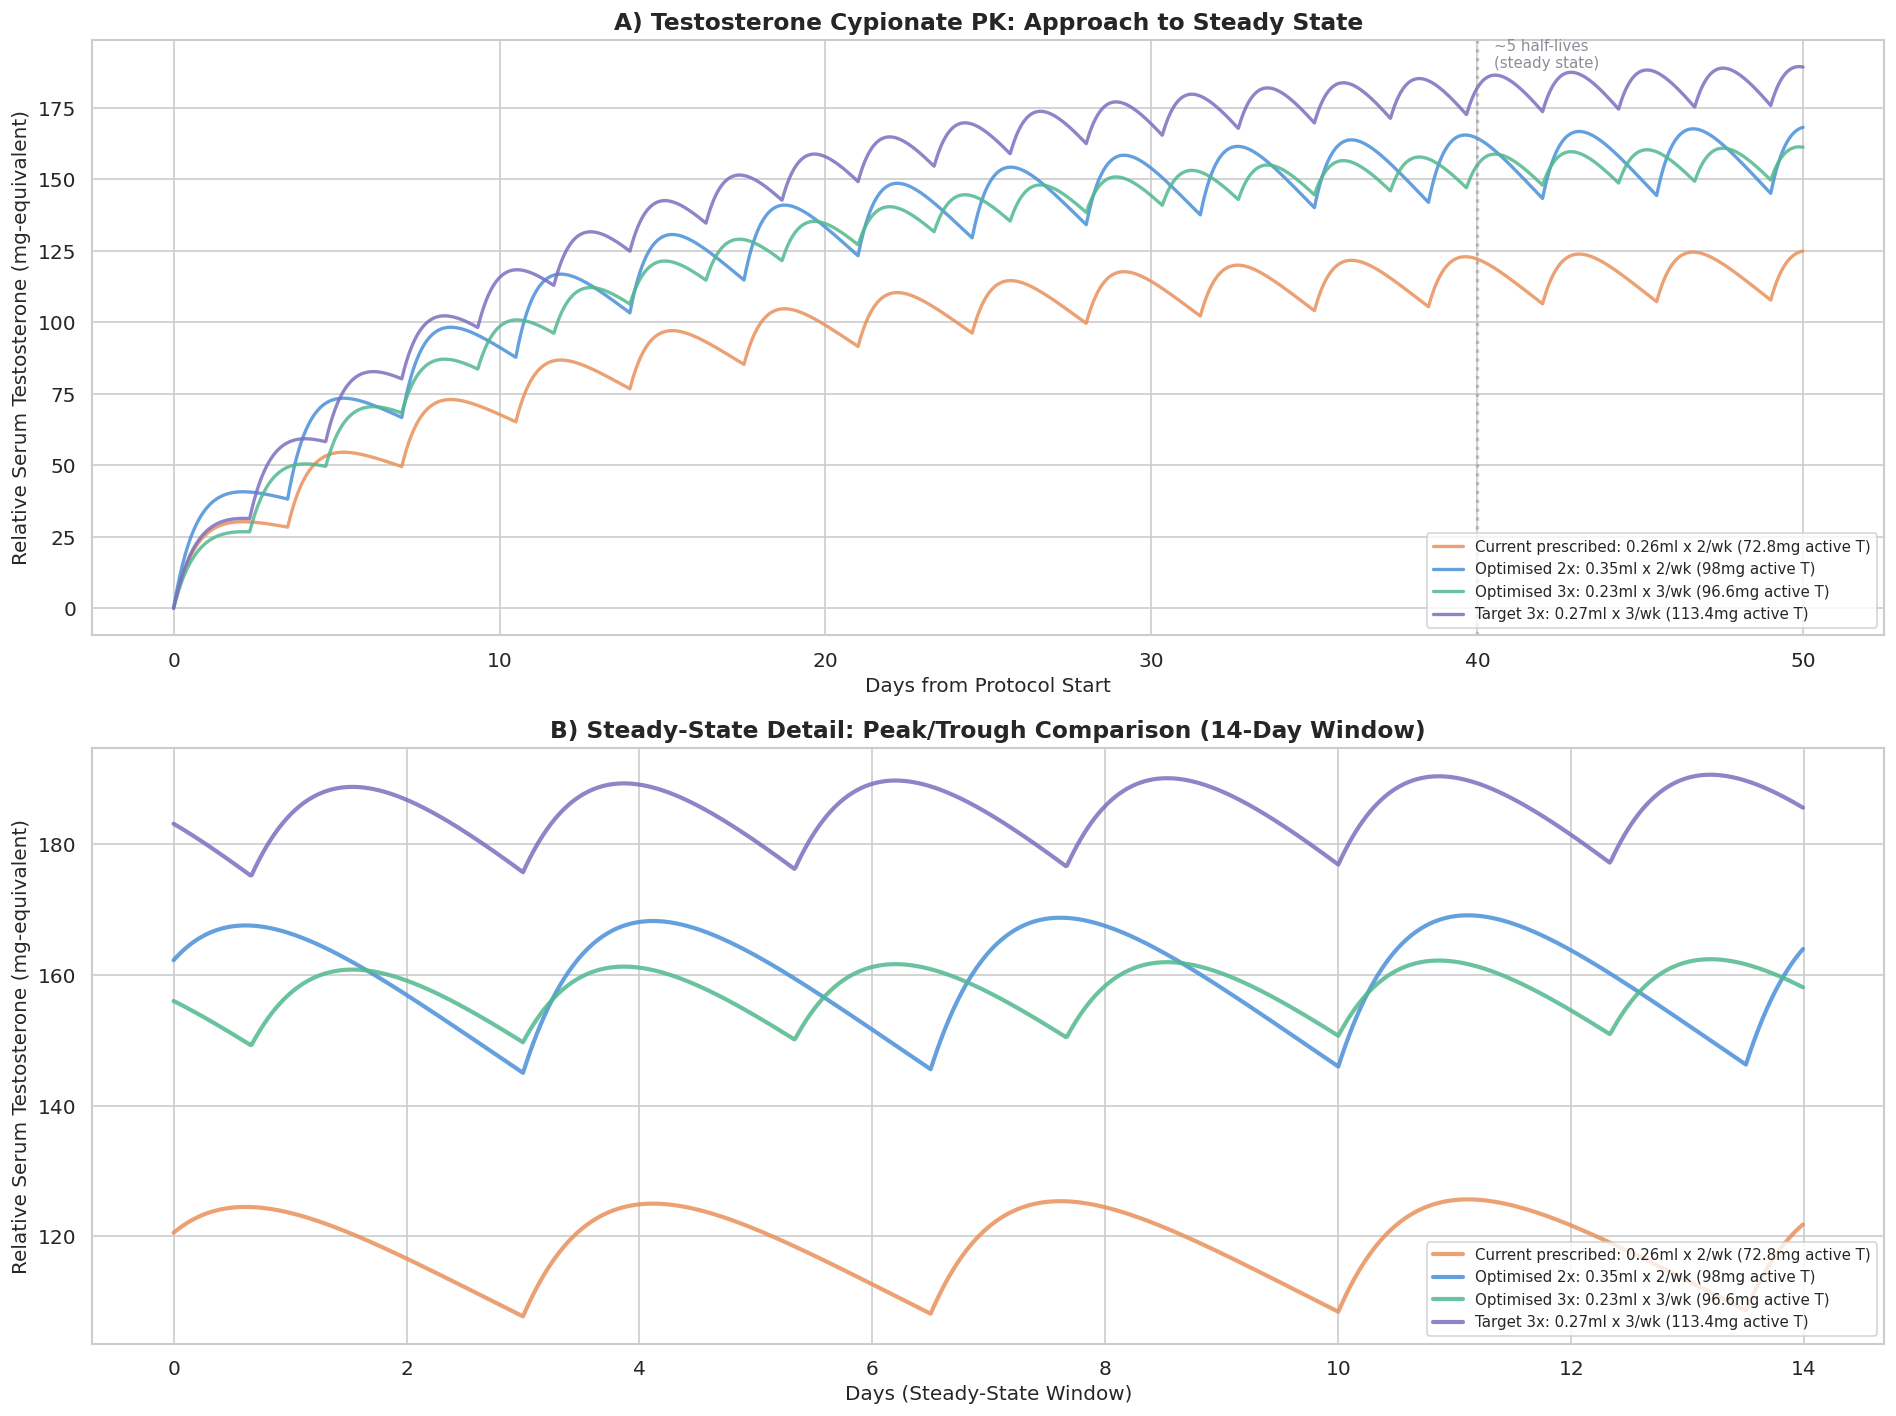

=== Injection Frequency PK Comparison ===
          Protocol  Dose/inj (ml)  Freq  Weekly mg active T  Peak (rel)  Trough (rel) Peak:Trough  Fluctuation %
Current prescribed           0.26 2x/wk                72.8      125.64        107.72      1.17:1           15.1
      Optimised 2x           0.35 2x/wk                98.0      169.13        145.01      1.17:1           15.1
      Optimised 3x           0.23 3x/wk                96.6      162.41        149.27      1.09:1            8.3
         Target 3x           0.27 3x/wk               113.4      190.65        175.24      1.09:1            8.3


In [16]:
# --- Injection Frequency PK Simulation ---

HALF_LIFE_DAYS = 8.0
DECAY_CONSTANT = np.log(2) / HALF_LIFE_DAYS
CONC_MG_ML = 200
ESTER_FACTOR_PK = 0.70

# Absorption: model peak at ~36h post-injection, simple absorption-then-decay
ABSORPTION_HALF_LIFE = 0.5  # days (rapid subcutaneous absorption)
ABSORPTION_K = np.log(2) / ABSORPTION_HALF_LIFE


def simulate_steady_state(dose_per_injection_ml, injections_per_week, days=60, dt=0.01):
    """Simulate TC serum level using superposition of exponential decay curves.
    Uses a one-compartment model with first-order absorption and elimination.
    Returns time array (days) and relative serum concentration."""
    
    mg_per_injection = dose_per_injection_ml * CONC_MG_ML * ESTER_FACTOR_PK
    interval_days = 7.0 / injections_per_week
    
    t = np.arange(0, days, dt)
    concentration = np.zeros_like(t)
    
    # Superimpose contribution from each injection
    n_injections = int(np.ceil(days / interval_days)) + 1
    for i in range(n_injections):
        t_inject = i * interval_days
        mask = t >= t_inject
        tau = t[mask] - t_inject
        # Bateman equation: C(t) = D * ka * (e^{-ke*t} - e^{-ka*t}) / (ka - ke)
        contribution = mg_per_injection * ABSORPTION_K * (
            np.exp(-DECAY_CONSTANT * tau) - np.exp(-ABSORPTION_K * tau)
        ) / (ABSORPTION_K - DECAY_CONSTANT)
        concentration[mask] += contribution
    
    return t, concentration


# --- Scenarios ---
scenarios = {
    "Current prescribed: 0.26ml x 2/wk (72.8mg active T)": (0.26, 2, ORANGE),
    "Optimised 2x: 0.35ml x 2/wk (98mg active T)": (0.35, 2, BLUE),
    "Optimised 3x: 0.23ml x 3/wk (96.6mg active T)": (0.23, 3, GREEN),
    "Target 3x: 0.27ml x 3/wk (113.4mg active T)": (0.27, 3, PURPLE),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Plot A: Full timeline to steady state ---
ax = axes[0]
for label, (dose_ml, freq, colour) in scenarios.items():
    t, conc = simulate_steady_state(dose_ml, freq, days=50)
    ax.plot(t, conc, color=colour, linewidth=2, label=label, alpha=0.85)

ax.set_xlabel("Days from Protocol Start")
ax.set_ylabel("Relative Serum Testosterone (mg-equivalent)")
ax.set_title("A) Testosterone Cypionate PK: Approach to Steady State", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.axvline(x=40, color=GREY, linestyle=":", alpha=0.5)
ax.text(40.5, ax.get_ylim()[1] * 0.95, "~5 half-lives\n(steady state)", fontsize=9, color=GREY)

# --- Plot B: Steady-state detail (last 14 days) ---
ax = axes[1]
pk_summary = []
for label, (dose_ml, freq, colour) in scenarios.items():
    t, conc = simulate_steady_state(dose_ml, freq, days=60)
    # Extract last 14 days at steady state
    ss_mask = t >= 46
    t_ss = t[ss_mask] - t[ss_mask].min()
    c_ss = conc[ss_mask]
    ax.plot(t_ss, c_ss, color=colour, linewidth=2.5, label=label, alpha=0.85)
    
    # Calculate peak/trough metrics
    peak = c_ss.max()
    trough = c_ss.min()
    mean_c = c_ss.mean()
    ratio = peak / trough if trough > 0 else float("inf")
    fluctuation = (peak - trough) / mean_c * 100
    pk_summary.append({
        "Protocol": label.split(":")[0].strip(),
        "Dose/inj (ml)": dose_ml,
        "Freq": f"{freq}x/wk",
        "Weekly mg active T": round(dose_ml * CONC_MG_ML * ESTER_FACTOR_PK * freq, 1),
        "Peak (rel)": round(peak, 2),
        "Trough (rel)": round(trough, 2),
        "Peak:Trough": f"{ratio:.2f}:1",
        "Fluctuation %": round(fluctuation, 1),
    })

ax.set_xlabel("Days (Steady-State Window)")
ax.set_ylabel("Relative Serum Testosterone (mg-equivalent)")
ax.set_title("B) Steady-State Detail: Peak/Trough Comparison (14-Day Window)", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- PK Summary Table ---
pk_df = pd.DataFrame(pk_summary)
print("=== Injection Frequency PK Comparison ===")
print(pk_df.to_string(index=False))

=== Dose-Response: Cofactors ON vs OFF ===
WITH cofactors (Aug 2025):    0.295 nmol/mg  (SHBG=23.2)
WITHOUT cofactors (May 2026): 0.162 nmol/mg  (SHBG=32.1)
Cofactor boost factor:        1.82x

Note: May 2026 blood drawn at actual dose of 78.4mg/wk (prescribed: 72.8mg/wk)

=== Required Dose to Reach BSSM Targets (WITHOUT Cofactors) ===
Using unsuppressed ratio: 0.162 nmol/mg
  BSSM minimum trough (15 nmol/L): ~93mg active T/wk = 132mg cypionate
    -> 2x/wk: 0.33ml per injection
    -> 3x/wk: 0.22ml per injection
    -> +27% increase from prescribed dose
  BSSM mid-range (20 nmol/L): ~123mg active T/wk = 176mg cypionate
    -> 2x/wk: 0.44ml per injection
    -> 3x/wk: 0.29ml per injection
    -> +70% increase from prescribed dose
  BSSM upper-mid (25 nmol/L): ~154mg active T/wk = 220mg cypionate
    -> 2x/wk: 0.55ml per injection
    -> 3x/wk: 0.37ml per injection
    -> +112% increase from prescribed dose


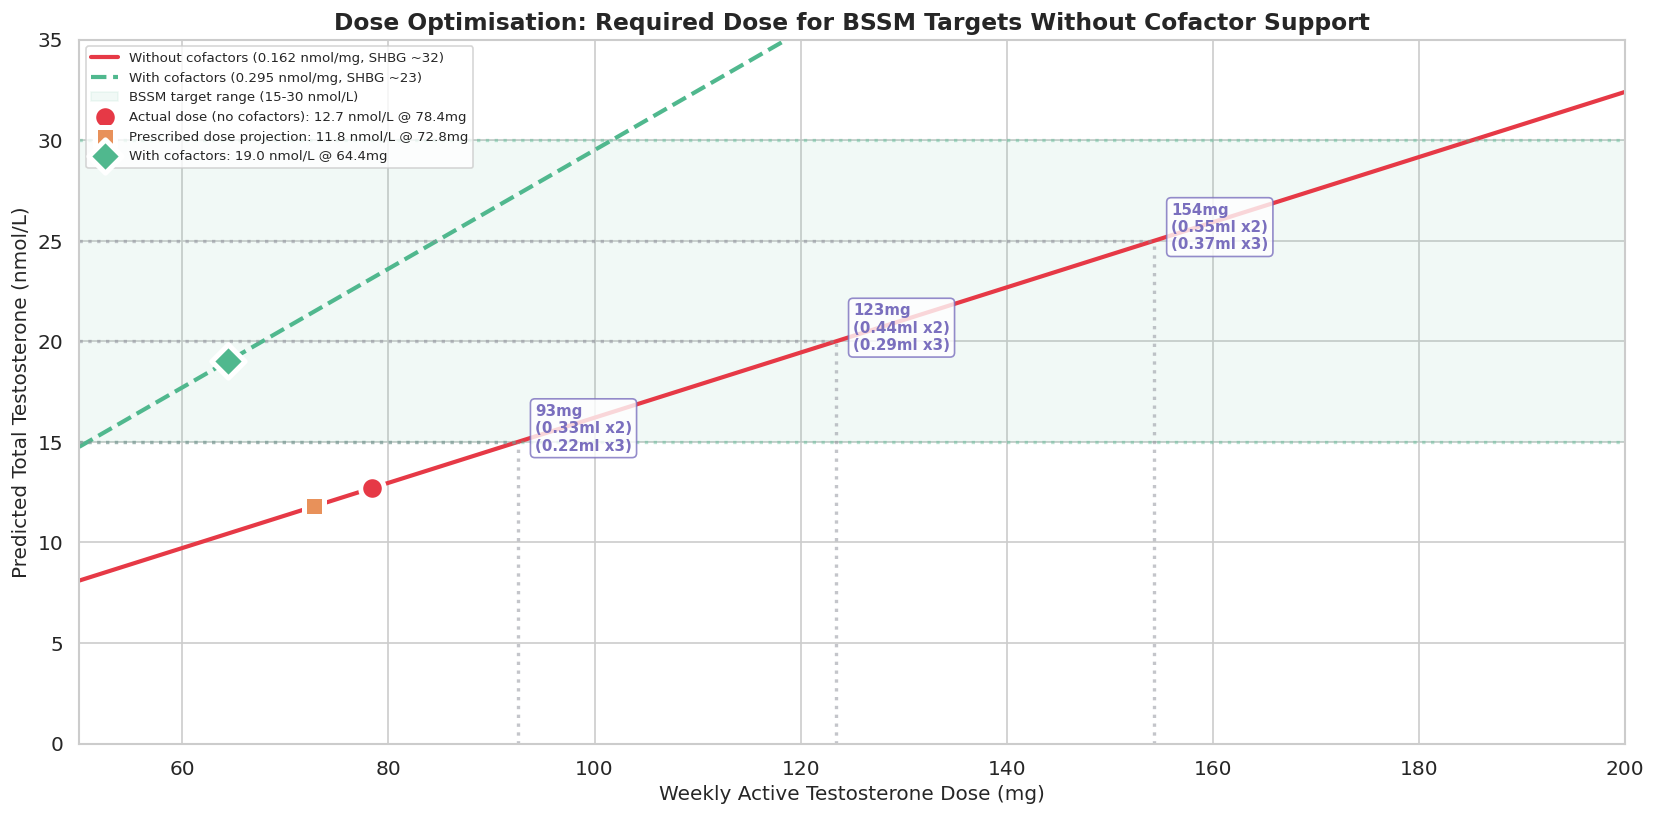


--- BSSM-Aligned Titration Plan (from prescribed dose) ---
Prescribed: 72.8mg active T/wk (104mg cypionate)
Actual:     78.4mg active T/wk (112mg cypionate) [misread]
Latest trough: 12.7 nmol/L (BELOW BSSM minimum of 15)

BSSM guidance: increase dose by 10-25%, retest at 6-12 weeks (Hackett et al., 2023)

Suggested titration steps from prescribed dose (25% per step):
  Step 1: 91mg active T/wk (130mg cypionate, 0.33ml x 2/wk)
    -> Predicted trough: ~14.7 nmol/L
  Step 2 (if needed): 114mg active T/wk (162mg cypionate, 0.41ml x 2/wk)
    -> Predicted trough: ~18.4 nmol/L

Safety: haematocrit currently 46.7% — well below BSSM ceiling of 54%


In [17]:
# --- Dose Optimisation: What dose achieves BSSM targets WITHOUT cofactors? ---

# Blood results correspond to ACTUAL dose taken (0.28ml = 78.4mg active T)
# Prescribed dose was 0.26ml = 72.8mg active T (misread led to 0.28ml)
# Use actual dose for PK ratio since blood was drawn at that dose

latest_t = 12.7      # nmol/L
actual_dose = 78.4   # mg active T/week (what was actually injected)
prescribed_dose = 72.8  # mg active T/week (what was prescribed)
latest_shbg = 32.1   # nmol/L (unsuppressed)
unsuppressed_ratio = latest_t / actual_dose  # true PK ratio based on actual dosing

# Contrast with Aug 2025: T=19.0 at 64.4mg/wk with SHBG=23.2 (cofactors active)
cofactor_t = 19.0
cofactor_dose = 64.4
cofactor_ratio = cofactor_t / cofactor_dose  # nmol per mg WITH cofactor help

print("=== Dose-Response: Cofactors ON vs OFF ===")
print(f"WITH cofactors (Aug 2025):    {cofactor_ratio:.3f} nmol/mg  (SHBG=23.2)")
print(f"WITHOUT cofactors (May 2026): {unsuppressed_ratio:.3f} nmol/mg  (SHBG=32.1)")
print(f"Cofactor boost factor:        {cofactor_ratio/unsuppressed_ratio:.2f}x")
print(f"\nNote: May 2026 blood drawn at actual dose of {actual_dose}mg/wk (prescribed: {prescribed_dose}mg/wk)")

# Calculate required doses for BSSM targets WITHOUT cofactor support
print("\n=== Required Dose to Reach BSSM Targets (WITHOUT Cofactors) ===")
print(f"Using unsuppressed ratio: {unsuppressed_ratio:.3f} nmol/mg")
targets = [
    ("BSSM minimum trough (15 nmol/L)", 15),
    ("BSSM mid-range (20 nmol/L)", 20),
    ("BSSM upper-mid (25 nmol/L)", 25),
]

fig, ax = plt.subplots(figsize=(14, 7))
dose_range = np.linspace(50, 200, 200)

# Plot two dose-response lines: with and without cofactors
ax.plot(dose_range, dose_range * unsuppressed_ratio, color=RED, linewidth=2.5,
        label=f"Without cofactors ({unsuppressed_ratio:.3f} nmol/mg, SHBG ~32)")
ax.plot(dose_range, dose_range * cofactor_ratio, color=GREEN, linewidth=2.5, linestyle="--",
        label=f"With cofactors ({cofactor_ratio:.3f} nmol/mg, SHBG ~23)")

# Shade BSSM therapeutic zone
ax.axhspan(15, 30, alpha=0.08, color=GREEN, label="BSSM target range (15-30 nmol/L)")
ax.axhline(y=15, color=GREEN, linestyle=":", alpha=0.4)
ax.axhline(y=30, color=GREEN, linestyle=":", alpha=0.4)

# Mark current protocol - actual dose
ax.scatter([actual_dose], [latest_t], s=200, c=RED, zorder=10, edgecolors="white",
           linewidth=3, label=f"Actual dose (no cofactors): {latest_t} nmol/L @ {actual_dose}mg")
# Mark prescribed dose projection
prescribed_predicted = prescribed_dose * unsuppressed_ratio
ax.scatter([prescribed_dose], [prescribed_predicted], s=150, c=ORANGE, zorder=10, edgecolors="white",
           linewidth=3, marker="s", label=f"Prescribed dose projection: {prescribed_predicted:.1f} nmol/L @ {prescribed_dose}mg")
ax.scatter([cofactor_dose], [cofactor_t], s=200, c=GREEN, zorder=10, edgecolors="white",
           linewidth=3, marker="D", label=f"With cofactors: {cofactor_t} nmol/L @ {cofactor_dose}mg")

# Mark required doses for each target
for target_label, target_t in targets:
    required_mg = target_t / unsuppressed_ratio
    required_ml_2x = required_mg / ESTER_FACTOR_PK / CONC_MG_ML / 2
    required_ml_3x = required_mg / ESTER_FACTOR_PK / CONC_MG_ML / 3
    ax.plot([required_mg, required_mg], [0, target_t], ":", color=GREY, alpha=0.5)
    ax.plot([50, required_mg], [target_t, target_t], ":", color=GREY, alpha=0.5)
    ax.annotate(f"{required_mg:.0f}mg\n({required_ml_2x:.2f}ml x2)\n({required_ml_3x:.2f}ml x3)",
                (required_mg, target_t), textcoords="offset points", xytext=(10, -5),
                fontsize=9, fontweight="bold", color=PURPLE,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PURPLE, alpha=0.8))
    pct_increase = (required_mg - prescribed_dose) / prescribed_dose * 100
    print(f"  {target_label}: ~{required_mg:.0f}mg active T/wk = {required_mg/ESTER_FACTOR_PK:.0f}mg cypionate")
    print(f"    -> 2x/wk: {required_ml_2x:.2f}ml per injection")
    print(f"    -> 3x/wk: {required_ml_3x:.2f}ml per injection")
    print(f"    -> {pct_increase:+.0f}% increase from prescribed dose")

ax.set_xlabel("Weekly Active Testosterone Dose (mg)", fontsize=12)
ax.set_ylabel("Predicted Total Testosterone (nmol/L)", fontsize=12)
ax.set_title("Dose Optimisation: Required Dose for BSSM Targets Without Cofactor Support", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(50, 200)
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()

# BSSM-aligned titration plan from prescribed dose
print("\n--- BSSM-Aligned Titration Plan (from prescribed dose) ---")
print(f"Prescribed: {prescribed_dose:.1f}mg active T/wk ({prescribed_dose/ESTER_FACTOR_PK:.0f}mg cypionate)")
print(f"Actual:     {actual_dose:.1f}mg active T/wk ({actual_dose/ESTER_FACTOR_PK:.0f}mg cypionate) [misread]")
print(f"Latest trough: {latest_t} nmol/L (BELOW BSSM minimum of 15)")
print(f"\nBSSM guidance: increase dose by 10-25%, retest at 6-12 weeks (Hackett et al., 2023)")
step1 = prescribed_dose * 1.25
step2 = step1 * 1.25
print(f"\nSuggested titration steps from prescribed dose (25% per step):")
print(f"  Step 1: {step1:.0f}mg active T/wk ({step1/ESTER_FACTOR_PK:.0f}mg cypionate, {step1/ESTER_FACTOR_PK/CONC_MG_ML/2:.2f}ml x 2/wk)")
print(f"    -> Predicted trough: ~{step1 * unsuppressed_ratio:.1f} nmol/L")
print(f"  Step 2 (if needed): {step2:.0f}mg active T/wk ({step2/ESTER_FACTOR_PK:.0f}mg cypionate, {step2/ESTER_FACTOR_PK/CONC_MG_ML/2:.2f}ml x 2/wk)")
print(f"    -> Predicted trough: ~{step2 * unsuppressed_ratio:.1f} nmol/L")
print(f"\nSafety: haematocrit currently {bloodwork.dropna(subset=['haematocrit_pct']).iloc[-1]['haematocrit_pct']:.1f}% — well below BSSM ceiling of 54%")

---
## 13. Conclusions & Protocol Recommendations

### Summary of Findings

This analysis examines 15 months of TRT data (6 blood panels, continuous Oura biometrics, Hevy training logs, and nutrition data) to assess protocol adequacy against BSSM treatment targets.

---

### 1. Current Protocol Is Not Achieving BSSM Minimum Trough Target

The latest blood draw (May 2026) shows a trough total testosterone of **12.7 nmol/L** — below the BSSM-recommended on-treatment minimum of **15 nmol/L** (Hackett et al., 2017). Free testosterone (0.251 nmol/L) is also below typical targets. This result was obtained on the highest dose prescribed to date (0.28ml × 2/week, 78.4mg active T/week).

### 2. SHBG Rebound Following Cofactor Cessation

Between February and May 2026, five cofactor supplements were stopped (Boron, Zinc, Magnesium, Selenium, P5P). SHBG rose from 22.5 to 32.1 nmol/L (+43%), which is consistent with the expected cumulative effect from literature (+7.5–12.5 nmol/L; Naghii et al., 2011; Prasad et al., 1996; Excelmyer et al., 2021). This SHBG increase drove a 44% fall in free testosterone.

The key observation: **prior "adequate" blood results (T=17.7–19.0 nmol/L) were achieved only with cofactor-suppressed SHBG levels (~22–23 nmol/L)**. With SHBG at its natural, unsuppressed level (~32 nmol/L), the same dose produces sub-therapeutic results.

### 3. Dose-Response Without Cofactor Support

| Scenario | Dose (active T/wk) | SHBG | Total T | Dose-Response Ratio |
|---|---|---|---|---|
| With cofactors (Aug 2025) | 64.4 mg | 23.2 | 19.0 nmol/L | 0.295 nmol/mg |
| Without cofactors (May 2026) | 78.4 mg | 32.1 | 12.7 nmol/L | 0.162 nmol/mg |

The cofactor stack was providing an approximately 82% boost to dose-response efficiency. The base TRT dose appears insufficient to reliably achieve BSSM targets independently.

### 4. Safety Markers Remain Within Limits

Haematocrit (46.7%), haemoglobin (156 g/L), and PSA (1.56 µg/L with 0.79 rise over baseline) are all within BSSM safety thresholds (HCT < 54%, PSA rise < 1.4/12mo). There is safety headroom for a dose increase.

---

### Discussion Points for Manual Clinician Review

**A. Dose Titration**

The BSSM practical guide (Hackett et al., 2023) recommends dose increases of 10–25% with retesting at 6–12 weeks when trough levels are below target. Based on the current unsuppressed dose-response ratio:

| Target | Required Dose | Protocol (2x/wk) | Protocol (3x/wk) |
|---|---|---|---|
| 15 nmol/L (BSSM minimum) | ~93 mg active T/wk | 0.33ml × 2 | 0.22ml × 3 |
| 20 nmol/L (mid-range) | ~123 mg active T/wk | 0.44ml × 2 | 0.29ml × 3 |
| 25 nmol/L (upper-mid) | ~154 mg active T/wk | 0.55ml × 2 | 0.37ml × 3 |

A 25% dose increase (Step 1: ~98 mg active T/week, 0.35ml × 2/week) would be within BSSM titration guidance and is predicted to bring trough levels to approximately 15.9 nmol/L — just above the BSSM minimum. A second step may be required depending on response.

**B. Injection Frequency Consideration**

PK modelling with TC half-life of ~8 days (Kaminetsky et al., 2015) shows that switching from 2x/week to 3x/week at equivalent weekly doses reduces peak-trough fluctuation from ~15% to ~8%. Potential benefits include:
- Smoother serum levels, reducing oestradiol spikes at peak concentrations
- Smaller per-injection volume improving subcutaneous absorption
- Lower peak concentrations reducing haematocrit risk (Bachman et al., 2014)

This could be considered as a protocol refinement alongside dose adjustment.

**C. Cofactor Management**

If cofactors are resumed, they should be viewed as *additive* to an already-adequate base dose — not required for achieving minimum therapeutic levels. The goal is a protocol that produces BSSM-range trough levels on its own, with cofactors providing further optimisation.

---

### References

1. Hackett G et al. (2017) British Society for Sexual Medicine guidelines on adult testosterone deficiency, with statements for UK practice. *J Sex Med*. 14(12):1504-1523. DOI: 10.1016/j.jsxm.2017.10.067
2. Hackett G (2023) A practical guide to the assessment and management of testosterone deficiency. *Trends in Urology and Men's Health*. 14(3):6-11. BSSM.
3. Bhasin S et al. (2001) Testosterone dose-response relationships in healthy young men. *Am J Physiol Endocrinol Metab*. 281(6):E1172-81. DOI: 10.1152/ajpendo.2001.281.6.E1172
4. Naghii MR et al. (2011) Comparative effects of daily and weekly boron supplementation on plasma steroid hormones. *J Trace Elem Med Biol*. 25(1):54-58. DOI: 10.1007/s12011-011-8990-1
5. Prasad AS et al. (1996) Zinc status and serum testosterone levels of healthy adults. *Nutrition*. 12(5):344-348. DOI: 10.1016/S0899-9007(96)80058-X
6. Excelmyer CN et al. (2021) Magnesium intake is inversely associated with SHBG. *J Cell Biochem*. DOI: 10.1002/jcb.29790
7. Vermeulen A et al. (1999) A critical evaluation of simple methods for estimation of free testosterone. *J Clin Endocrinol Metab*. 84(10):3666-72. DOI: 10.1210/jcem.84.10.6029
8. Kaminetsky J et al. (2015) Pharmacokinetics of subcutaneous testosterone enanthate. *J Clin Endocrinol Metab*. 100(11):4091-4097. DOI: 10.1210/jc.2015-2781
9. Bachman E et al. (2014) Testosterone induces erythrocytosis via increased erythropoietin and suppressed hepcidin. *J Gerontol A Biol Sci Med Sci*. 69(6):725-735. DOI: 10.1093/gerona/glt154
10. Corona G et al. (2011) SHBG as determinant of testosterone bioavailability in TRT. *Clin Endocrinol*. DOI: 10.1111/j.1365-2265.2011.04060.x